# B-Scan Migration Playground – Subwavelength PSF **Diagonal** TimeLapse Analysis

**Purpose:** Quantify the detection limit of **diagonal** (combined lateral + vertical) subwavelength scatterer movement using three migration methods.

A single PEC cylinder at **x = 2.0 m**, baseline depth **y = 0.224 m** in gprMax coordinates (i.e. 0.676 m below the ice surface) moves diagonally — to the right *and* downward simultaneously — by fractions of the wavelength:

| Scenario | Δx (right) | Δy (down) |
|----------|-----------|-----------|
| Baseline | 0 | 0 |
| 1 | 1 λ | ½ λ |
| 2 | ½ λ | ¼ λ |
| 3 | ¼ λ | ⅛ λ |
| 4 | ⅛ λ | ¹⁄₁₆ λ |
| 5 | ¹⁄₁₆ λ | ¹⁄₃₂ λ |

Each scenario is an independent diagonal displacement from the same baseline position (not cumulative).

Methods tested:
- **Kirchhoff** delay-and-sum (PyLops zero-offset operator)
- **Gazdag** phase-shift (f-k domain, exploding-reflector half-velocity)
- **Back-propagation** time-reversal (gprMax re-injection)

Each method produces a migrated image; the *time-lapse difference* (monitor − baseline) is analysed via a **diagonal PSF profile** sampled along the direction of motion.


# Input File Creation

In [1]:
import os, time as _time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import pyvista as pv
from gprMax.gprMax import api
from tools.outputfiles_merge import merge_files
from tools.plot_Bscan import get_output_data, mpl_plot


In [2]:
# ── Standard figure auto-save (protocol: .wiki/FIGURES_PROTOCOL.md) ─────────
import sys, pathlib
if str(pathlib.Path.cwd()) not in sys.path:
    sys.path.insert(0, str(pathlib.Path.cwd()))
from helper_functions.figures import setup_autosave
setup_autosave(study="Diagonal_TimeLapse_Study", prefix="DTL_")


Figure autosave -> C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Figures\Diagonal_TimeLapse_Study  (prefix='DTL_', dpi=300)


In [3]:
from helper_functions.visualisation import (
    plot_domain_geometry, plot_bscan_grid, plot_migrated_grid, plot_wavefield_grid,
    plot_method_comparison_grid, plot_psf_grid, plot_spectrum_grid, plot_trace_comparison,
)


def _finish_markers(axes, baseline_xy, legend='all'):
    """This notebook's baseline and current scatterer positions differ in
    both x AND depth (diagonal motion), but plot_migrated_grid /
    plot_wavefield_grid's marker_x_baseline assumes a *shared* depth between
    baseline and current (see its docstring) -- so the true baseline marker
    is added here instead, on every visible panel, and each panel's legend
    is rebuilt to include it (matching this notebook's original per-cell
    legend placement: 'none', 'first', or 'all').
    """
    flat = np.atleast_1d(axes).ravel()
    for i, ax in enumerate(flat):
        if not ax.get_visible():
            continue
        ax.plot(*baseline_xy, 'g*', ms=10, zorder=5, label='baseline')
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()
        if legend == 'all' or (legend == 'first' and i == 0):
            ax.legend(fontsize=8, loc='upper right')


In [4]:
# Medium
eps_r      = 3.15
v_ice      = 0.299792458 / np.sqrt(eps_r)   # m/ns ≈ 0.16892
f_c_GHz    = 1.5                              # centre frequency [GHz]
wavelength = v_ice / f_c_GHz                  # m ≈ 0.1126
v_mig      = v_ice / 2                        # exploding-reflector half-velocity [m/ns]
t0_ns      = np.sqrt(2) / f_c_GHz            # Ricker peak delay [ns] ≈ 0.943

# Survey geometry
domain_x   = 4.0
n_traces   = 380
trace_step = 0.01   # m
rx_offset  = 0.1    # m (source-receiver offset in .in file)
x_traces   = (0.1 + rx_offset / 2) + np.arange(n_traces) * trace_step   # midpoints [m]

# Scatterer geometry (baseline)
x_baseline   = 2.000                          # baseline lateral position [m]
y_surface    = 0.9                            # air-ice interface [m from domain bottom]
y_baseline   = 0.224                          # baseline gprMax y of cylinder [m]
z_scatterer  = y_surface - y_baseline         # baseline depth below surface [m] ≈ 0.676
radius_scat  = wavelength / 40               # cylinder radius ≈ 0.0028 m
z_top        = z_scatterer - radius_scat      # baseline depth to cylinder top [m]

# Diagonal shifts: scenario i moves Δx = shifts_lambda_x[i]·λ to the right
# and Δy = shifts_lambda_y[i]·λ downward, independently from the baseline.
shifts_lambda_x = [1, 0.5, 0.25, 0.125, 0.0625]
shifts_lambda_y = [0.5, 0.25, 0.125, 0.0625, 0.03125]

x_scatterers_shift = [round(x_baseline + sx * wavelength, 3) for sx in shifts_lambda_x]
y_scatterers_shift = [round(y_baseline - sy * wavelength, 3) for sy in shifts_lambda_y]
z_depths_shift     = [round(y_surface - y, 3) for y in y_scatterers_shift]

labels     = ['Scenario 1 (1λx, ½λy)', 'Scenario 2 (½λx, ¼λy)', 'Scenario 3 (¼λx, ⅛λy)',
              'Scenario 4 (⅛λx, ¹⁄₁₆λy)', 'Scenario 5 (¹⁄₁₆λx, ¹⁄₃₂λy)']
labels_all = ['Baseline'] + labels
slugs_all  = ['baseline', 'scenario1', 'scenario2', 'scenario3', 'scenario4', 'scenario5']

# Migration depth grid
z_img = np.linspace(0.0, 0.9, 180)   # full ice thickness (0.9 m), same ~5 mm sample spacing

# Study root
STUDY_ROOT = Path(r'C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\diagonal_timelapse_study')

print(f'λ_ice        = {wavelength*1e3:.1f} mm')
print(f'v_ice        = {v_ice:.5f} m/ns,  v_mig = {v_mig:.5f} m/ns')
print(f't0_ns        = {t0_ns:.3f} ns')
print(f'z_scatterer  = {z_scatterer:.3f} m  (baseline centre),  z_top = {z_top:.4f} m')
print(f'x_traces     : {x_traces[0]:.3f} → {x_traces[-1]:.3f} m  ({n_traces} traces)')
print()
print('Scatterer positions (gprMax) and depths:')
print(f'  Baseline : x = {x_baseline:.3f} m   y = {y_baseline:.3f} m   depth = {z_scatterer:.3f} m')
for lbl, x, y, z in zip(labels, x_scatterers_shift, y_scatterers_shift, z_depths_shift):
    print(f'  {lbl:<28}: x = {x:.3f} m   y = {y:.3f} m   depth = {z:.3f} m')


λ_ice        = 112.6 mm
v_ice        = 0.16891 m/ns,  v_mig = 0.08446 m/ns
t0_ns        = 0.943 ns
z_scatterer  = 0.676 m  (baseline centre),  z_top = 0.6732 m
x_traces     : 0.150 → 3.940 m  (380 traces)

Scatterer positions (gprMax) and depths:
  Baseline : x = 2.000 m   y = 0.224 m   depth = 0.676 m
  Scenario 1 (1λx, ½λy)       : x = 2.113 m   y = 0.168 m   depth = 0.732 m
  Scenario 2 (½λx, ¼λy)       : x = 2.056 m   y = 0.196 m   depth = 0.704 m
  Scenario 3 (¼λx, ⅛λy)       : x = 2.028 m   y = 0.210 m   depth = 0.690 m
  Scenario 4 (⅛λx, ¹⁄₁₆λy)    : x = 2.014 m   y = 0.217 m   depth = 0.683 m
  Scenario 5 (¹⁄₁₆λx, ¹⁄₃₂λy) : x = 2.007 m   y = 0.220 m   depth = 0.680 m


## Calculate Geometry Factors

In [5]:
# CFL check
dx_required = (v_ice / 4.5) / 10  # based on 4 GHz (highest Ricker component) / 10
if 0.001 < dx_required:
    print('Discretisation is sufficiently small')
if radius_scat < dx_required:
    print('Scatterer radius is smaller than discretisation')

# gprMax (x, y) positions for each scenario (baseline + 5 diagonal shifts)
x_all = [x_baseline] + x_scatterers_shift
y_all = [y_baseline] + y_scatterers_shift


Discretisation is sufficiently small
Scatterer radius is smaller than discretisation


# Load Cached Results (optional shortcut)

In [6]:
# ── Load cached B-scan & migration results (skip re-running expensive cells) ──
# Loads the .npz archives written by the "Saving the Data" / "Save Migrated
# Results" cells further down, reconstructing every variable the plotting
# cells need — so the Kirchhoff/Gazdag migration cells (each runs a full
# adjoint / phase-shift inversion per scenario, timed at multiple seconds to
# minutes per scenario) and the raw-.out-file data-loading cells don't have
# to be re-executed just to re-plot already-computed results.
#
# With USE_CACHED_RESULTS = True you can skip straight from here to:
#   - the B-scan grid / tapering cells ("Visualisation" section)
#   - the Kirchhoff/Gazdag full-extent, zoomed, and timelapse-diff plots
#   - the noisy counterparts of all of the above
#
# NOT covered by these caches: back-propagation wavefield snapshots
# (focus_frames / focus_frames_noisy) and the "Analysis" comparison-grid /
# PSF section, which need the raw x-y-domain wavefield snapshots. Only a
# migration-grid-*reprojected* version of back-prop is cached (inside
# diagonal_difference_migrated_results.npz, written purely for archival),
# which is not in the format plot_wavefield_grid or the Analysis cells need.
# Run the cells under "Back-Propagation Migration" (clean/noisy) if you need
# those plots or the comparison grid / PSF section.
#
# Set USE_CACHED_RESULTS = False to fall back to the notebook's normal
# top-to-bottom execution (re-running data loading and migration).

USE_CACHED_RESULTS = True

if USE_CACHED_RESULTS:
    _static   = np.load(STUDY_ROOT / 'static_results.npz')
    _static_n = np.load(STUDY_ROOT / 'static_results_noisy.npz')
    _mig      = np.load(STUDY_ROOT / 'diagonal_migrated_results.npz')
    _mig_diff = np.load(STUDY_ROOT / 'diagonal_difference_migrated_results.npz')
    _mig_n    = np.load(STUDY_ROOT / 'migrated_results_noisy.npz')

    # -- Background-subtracted B-scans (clean / noisy) --------------------------
    data_static    = list(zip(labels_all, _static['data_static']))
    data_noisy     = list(zip(labels_all, _static_n['data_static']))
    outputs_static = [d for _, d in data_static]
    outputs_noisy  = [d for _, d in data_noisy]

    time_ns     = _static['time_ns']
    dt          = float(_static['dt'])
    dt_ns       = dt * 1e9
    n_t         = outputs_static[0].shape[0]
    NOISE_LEVEL = float(_static_n['noise_level'])

    # z_depths_all is normally computed inside the Kirchhoff migration cell;
    # reconstruct it here since that cell is being skipped.
    z_depths_all = [z_scatterer] + z_depths_shift
    t_apex       = [2 * z / v_ice for z in z_depths_all]

    # -- Migrated images: clean, noisy, and timelapse differences ---------------
    migrated          = dict(zip(_mig['scenarios'],      _mig['kirchhoff']))
    migrated_gz       = dict(zip(_mig['scenarios'],      _mig['gazdag']))
    migrated_noisy    = dict(zip(_mig_n['scenarios'],    _mig_n['kirchhoff']))
    migrated_gz_noisy = dict(zip(_mig_n['scenarios'],    _mig_n['gazdag']))
    migrated_diff     = dict(zip(_mig_diff['scenarios'], _mig_diff['kirchhoff_diff']))
    migrated_gz_diff  = dict(zip(_mig_diff['scenarios'], _mig_diff['gazdag_diff']))

    extent_mig   = [x_traces[0], x_traces[-1], z_img[-1], z_img[0]]
    extent_bscan = [x_traces[0], x_traces[-1], time_ns[-1], 0]
    _migrated_baseline_xy = (x_all[0], z_depths_all[0])

    # Kirchhoff aperture half-angle [degrees], only used for display in plot
    # titles here -- must match the "Tapering & t0 Shift" cell's value if you
    # later re-run the migration and want title text to stay consistent.
    ANGLE_AP = 40

    print('Loaded cached results from', STUDY_ROOT)
    print(f'  data_static / data_noisy           : {len(data_static)} scenarios each')
    print(f'  migrated / migrated_gz             : {len(migrated)} scenarios each')
    print(f'  migrated_noisy / migrated_gz_noisy : {len(migrated_noisy)} scenarios each')
    print(f'  migrated_diff / migrated_gz_diff   : {len(migrated_diff)} scenarios each')
    print('  Back-propagation and the Analysis section still need the cells under')
    print('  "Back-Propagation Migration" -- raw wavefield snapshots are not cached.')

Loaded cached results from C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\diagonal_timelapse_study
  data_static / data_noisy           : 6 scenarios each
  migrated / migrated_gz             : 6 scenarios each
  migrated_noisy / migrated_gz_noisy : 6 scenarios each
  migrated_diff / migrated_gz_diff   : 5 scenarios each
  Back-propagation and the Analysis section still need the cells under
  "Back-Propagation Migration" -- raw wavefield snapshots are not cached.


## Background model (no scatterers)

In [ ]:
%%writefile diagonal_timelapse_study/background/background.in

#title: GPR Diagonal TimeLapse Study - background
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:


#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 background n
#messages: y


## Baseline (static scatterer at x = 2.0 m, y = 0.224 m)

In [ ]:
%%writefile diagonal_timelapse_study/baseline/baseline.in

#title: GPR Diagonal TimeLapse Study - baseline
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Single point scatterer (PEC)
#cylinder: 2.000 0.224 0 2.000 0.224 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:


#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 baseline n
#messages: y


## Scenario 1: 1λ right, ½λ down

In [ ]:
%%writefile diagonal_timelapse_study/scenario1/scenario1.in

#title: GPR Diagonal TimeLapse Study - Scenario 1 (1λ right, ½λ down)
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Single point scatterer (PEC)
#cylinder: 2.113 0.168 0 2.113 0.168 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:


#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 scenario1 n
#messages: y


## Scenario 2: ½λ right, ¼λ down

In [ ]:
%%writefile diagonal_timelapse_study/scenario2/scenario2.in

#title: GPR Diagonal TimeLapse Study - Scenario 2 (½λ right, ¼λ down)
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Single point scatterer (PEC)
#cylinder: 2.056 0.196 0 2.056 0.196 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:


#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 scenario2 n
#messages: y


## Scenario 3: ¼λ right, ⅛λ down

In [ ]:
%%writefile diagonal_timelapse_study/scenario3/scenario3.in

#title: GPR Diagonal TimeLapse Study - Scenario 3 (¼λ right, ⅛λ down)
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Single point scatterer (PEC)
#cylinder: 2.028 0.210 0 2.028 0.210 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:


#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 scenario3 n
#messages: y


## Scenario 4: ⅛λ right, ¹⁄₁₆λ down

In [ ]:
%%writefile diagonal_timelapse_study/scenario4/scenario4.in

#title: GPR Diagonal TimeLapse Study - Scenario 4 (⅛λ right, ¹⁄₁₆λ down)
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Single point scatterer (PEC)
#cylinder: 2.014 0.217 0 2.014 0.217 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:


#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 scenario4 n
#messages: y


## Scenario 5: ¹⁄₁₆λ right, ¹⁄₃₂λ down

In [ ]:
%%writefile diagonal_timelapse_study/scenario5/scenario5.in

#title: GPR Diagonal TimeLapse Study - Scenario 5 (¹⁄₁₆λ right, ¹⁄₃₂λ down)
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Single point scatterer (PEC)
#cylinder: 2.007 0.220 0 2.007 0.220 0.001 0.0028 pec

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:


#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 scenario5 n
#messages: y


# Visualising Model Geometry

  [saved] Diagonal_TimeLapse_Study\General\DTL_001_Diagonal_TimeLapse_Study__Model_Geometry__domain_4010_m_Δx.png


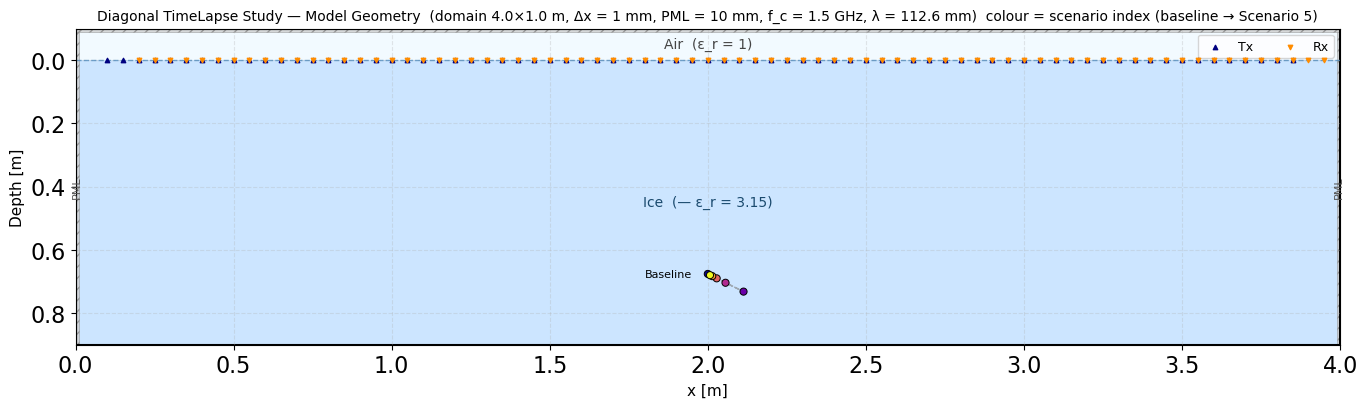

  [saved] Diagonal_TimeLapse_Study\General\DTL_002_Diagonal_scatterer_path__all_6_scenarios__r__28_mm.png


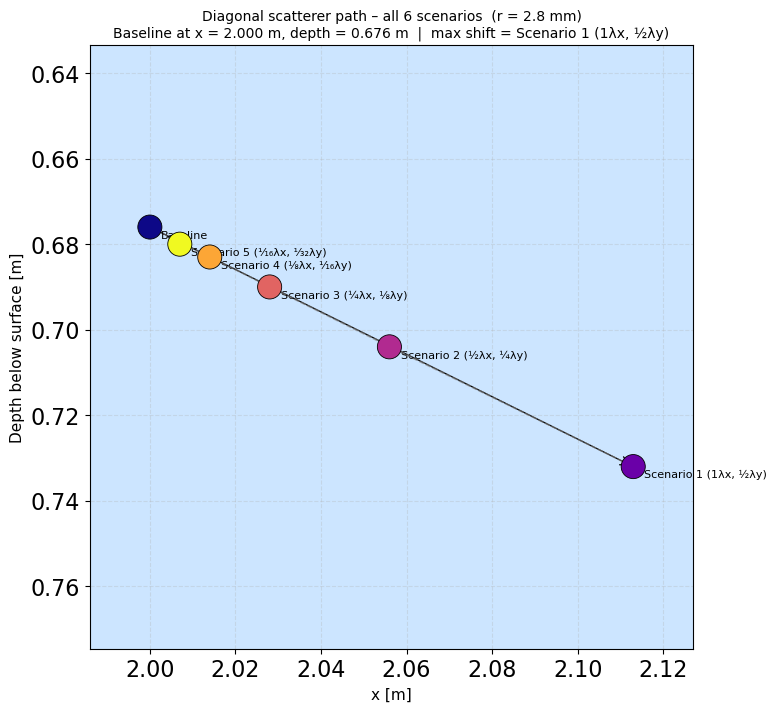

In [7]:
from matplotlib.patches import Rectangle, Circle
import matplotlib.pyplot as plt

# ── Geometry constants ────────────────────────────────────────────────────────
domain_y   = 1.0
dx_grid    = 0.001
pml_t      = 10 * dx_grid   # = 0.010 m
air_h      = domain_y - y_surface   # = 0.1 m
rx_off     = 0.1

# Depth coordinate (0 = ice surface, positive = deeper)
d_top  = -air_h           # -0.1 m

# All positions and depth labels
_x_all  = [x_baseline] + x_scatterers_shift
_z_all  = [z_scatterer] + z_depths_shift
_labels = ['Baseline'] + labels
cmap_pts = plt.cm.plasma

# ── Figure 1: Full domain cross-section ──────────────────────────────────────
x_src_arr = 0.100 + np.arange(n_traces) * trace_step
fig1, ax1 = plot_domain_geometry(domain_x, domain_y, y_surface, pml_t,
                                  x_src=x_src_arr, rx_offset=rx_off, tx_stride=5,
                                  eps_r=eps_r, figsize=(14, 4))

# Diagonal motion path + scenario markers (radius x4 for visibility)
r_vis = 4 * radius_scat
ax1.plot(_x_all, _z_all, color='grey', lw=1.0, ls='--', alpha=0.6, zorder=4)
for i, (lbl, x, z) in enumerate(zip(_labels, _x_all, _z_all)):
    col = cmap_pts(i / (len(_labels) - 1))
    ax1.add_patch(Circle((x, z), r_vis, facecolor=col, edgecolor='black', lw=0.7, zorder=5))

ax1.text(_x_all[0] - 0.05, _z_all[0], 'Baseline', ha='right', va='center', fontsize=8)

ax1.set_xlim(0, domain_x)
ax1.set_ylim(y_surface, d_top)
ax1.set_xlabel('x [m]', fontsize=11)
ax1.set_ylabel('Depth [m]', fontsize=11)
ax1.set_title(
    f'Diagonal TimeLapse Study — Model Geometry  '
    f'(domain {domain_x:.1f}×{domain_y:.1f} m, Δx = {dx_grid*1e3:.0f} mm, '
    f'PML = {pml_t*1e3:.0f} mm, f_c = {f_c_GHz} GHz, λ = {wavelength*1e3:.1f} mm)  '
    f'colour = scenario index (baseline → Scenario 5)',
    fontsize=10
)
ax1.set_aspect('equal', adjustable='box')
ax1.legend(loc='upper right', fontsize=9, ncol=2)
ax1.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Figure 2: Zoomed – diagonal scatterer path ───────────────────────────────
x_min, x_max = min(_x_all), max(_x_all)
z_min, z_max = min(_z_all), max(_z_all)
x_cen, z_cen = (x_min + x_max) / 2, (z_min + z_max) / 2
half_w = max((x_max - x_min) / 2 + 5 * radius_scat, (z_max - z_min) / 2 + 5 * radius_scat, 8 * radius_scat)

fig2, ax2 = plt.subplots(figsize=(8, 8))

ax2.add_patch(Rectangle((x_cen - half_w, z_cen - half_w), 2 * half_w, 2 * half_w,
                         facecolor='#cce5ff', edgecolor='#aac', lw=0.5))
ax2.plot(_x_all, _z_all, color='grey', lw=1.0, ls='--', alpha=0.6, zorder=4)

for i, (lbl, x, z) in enumerate(zip(_labels, _x_all, _z_all)):
    col = cmap_pts(i / (len(_labels) - 1))
    ax2.add_patch(Circle((x, z), radius_scat, facecolor=col, edgecolor='black', lw=0.6, zorder=5))
    ax2.annotate(lbl, (x, z), textcoords='offset points', xytext=(8, -8),
                 fontsize=8, rotation=0)

# Max-shift arrow (baseline → Scenario 1)
ax2.annotate('', xy=(_x_all[1], _z_all[1]), xytext=(_x_all[0], _z_all[0]),
             arrowprops=dict(arrowstyle='->', color='k', lw=0.9))

ax2.set_xlim(x_cen - half_w, x_cen + half_w)
ax2.set_ylim(z_cen + half_w, z_cen - half_w)
ax2.set_xlabel('x [m]', fontsize=11)
ax2.set_ylabel('Depth below surface [m]', fontsize=11)
ax2.set_title(
    f'Diagonal scatterer path – all 6 scenarios  '
    f'(r = {radius_scat*1e3:.1f} mm)\n'
    f'Baseline at x = {x_baseline:.3f} m, depth = {z_scatterer:.3f} m  |  max shift = Scenario 1 (1λx, ½λy)',
    fontsize=10
)
ax2.set_aspect('equal', adjustable='box')
ax2.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
plt.show()


# Generating Geometry Files and Merged B-scans
Only uncomment and run when necessary.

In [ ]:
# Uncomment and run to execute gprMax simulations for each scenario.
# Each scenario requires n_traces = 380 model runs.

# from gprMax.gprMax import api
# api(r'diagonal_timelapse_study/background/background.in', n=1, geometry_only=True)
# api(r'diagonal_timelapse_study/baseline/baseline.in', n=1, geometry_only=True)
# api(r'diagonal_timelapse_study/scenario1/scenario1.in', n=1, geometry_only=True)
# api(r'diagonal_timelapse_study/scenario2/scenario2.in', n=1, geometry_only=True)
# api(r'diagonal_timelapse_study/scenario3/scenario3.in', n=1, geometry_only=True)
# api(r'diagonal_timelapse_study/scenario4/scenario4.in', n=1, geometry_only=True)
# api(r'diagonal_timelapse_study/scenario5/scenario5.in', n=1, geometry_only=True)


In [ ]:
# Uncomment and run to merge per-trace .out files into a single merged .out file.

# from tools.outputfiles_merge import merge_files
# merge_files(r'diagonal_timelapse_study/background/background', True)
# merge_files(r'diagonal_timelapse_study/baseline/baseline', True)
# merge_files(r'diagonal_timelapse_study/scenario1/scenario1', True)
# merge_files(r'diagonal_timelapse_study/scenario2/scenario2', True)
# merge_files(r'diagonal_timelapse_study/scenario3/scenario3', True)
# merge_files(r'diagonal_timelapse_study/scenario4/scenario4', True)
# merge_files(r'diagonal_timelapse_study/scenario5/scenario5', True)


# Loading in the data and removing direct wave

In [8]:
rxnumber    = 1
rxcomponent = 'Ez'

output_background, dt = get_output_data(
    'diagonal_timelapse_study/background/background_merged.out', rxnumber, rxcomponent
)

_paths = [
    'diagonal_timelapse_study/baseline/baseline_merged.out',
    'diagonal_timelapse_study/scenario1/scenario1_merged.out',
    'diagonal_timelapse_study/scenario2/scenario2_merged.out',
    'diagonal_timelapse_study/scenario3/scenario3_merged.out',
    'diagonal_timelapse_study/scenario4/scenario4_merged.out',
    'diagonal_timelapse_study/scenario5/scenario5_merged.out',
]
raw_outputs    = [get_output_data(p, rxnumber, rxcomponent)[0] for p in _paths]
outputs_static = [r - output_background for r in raw_outputs]   # background-subtracted

dt_ns   = dt * 1e9
n_t     = outputs_static[0].shape[0]
time_ns = np.arange(n_t) * dt_ns

data_pre    = [('Background', output_background)] + list(zip(labels_all, raw_outputs))
data_static = list(zip(labels_all, outputs_static))

print(f'dt = {dt_ns:.6f} ns,  n_t = {n_t},  t_max = {time_ns[-1]:.2f} ns')
print(f'Data shape (n_t × n_tr): {outputs_static[0].shape}')

# Expected apex arrival times for each scenario (2 * depth / v_ice)
t_apex = [2 * z / v_ice for z in [z_scatterer] + z_depths_shift]
print('\nExpected apex arrival times:')
for lbl, t in zip(labels_all, t_apex):
    print(f'  {lbl:<28}: {t:.3f} ns')


dt = 0.002359 ns,  n_t = 8481,  t_max = 20.00 ns
Data shape (n_t × n_tr): (8481, 380)

Expected apex arrival times:
  Baseline                    : 8.004 ns
  Scenario 1 (1λx, ½λy)       : 8.667 ns
  Scenario 2 (½λx, ¼λy)       : 8.336 ns
  Scenario 3 (¼λx, ⅛λy)       : 8.170 ns
  Scenario 4 (⅛λx, ¹⁄₁₆λy)    : 8.087 ns
  Scenario 5 (¹⁄₁₆λx, ¹⁄₃₂λy) : 8.051 ns


# Importing Noise

In [9]:
import pickle
from scipy import stats
with open('laplace_noise_model.pkl', 'rb') as f:
    noise_model = pickle.load(f)

with open('laplace_noise_model_pre_gain.pkl', 'rb') as f:
    noise_model_pre_gain = pickle.load(f)


# Visualisation

c:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\helper_functions\visualisation.py:316: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  [saved] Diagonal_TimeLapse_Study\General\DTL_003_GPR_B-Scans__Background_Baseline_and_Diagonal_TimeLapsed_Mod.png


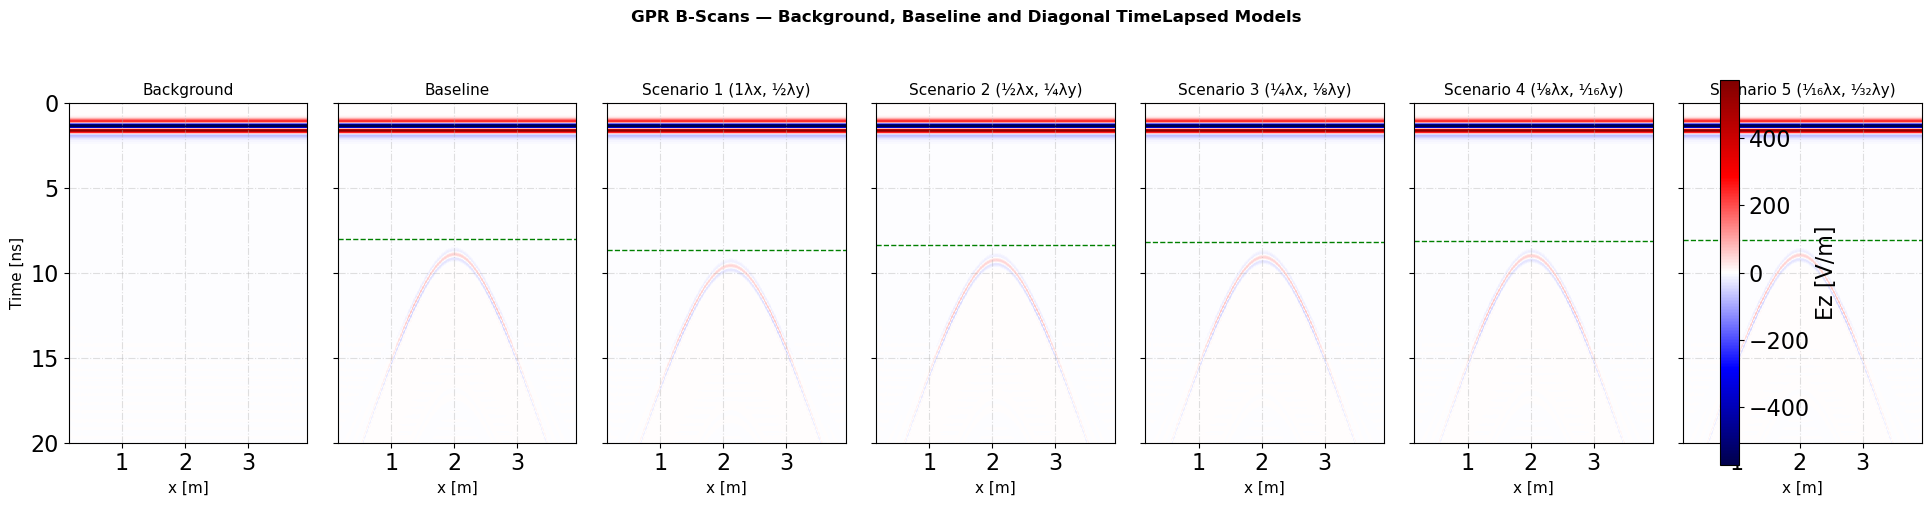

In [10]:
extent_bscan = [x_traces[0], x_traces[-1], time_ns[-1], 0]

def _apex_marker(ax, i):
    if i > 0:  # mark expected apex time for each scenario
        ax.axhline(t_apex[i - 1], color='green', linestyle='--', linewidth=1)

fig, axes = plot_bscan_grid(
    data_pre, x_traces, time_ns,
    title='GPR B-Scans — Background, Baseline and Diagonal TimeLapsed Models',
    markers=[_apex_marker] * len(data_pre),
)
plt.show()


  [saved] Diagonal_TimeLapse_Study\General\DTL_004_GPR_B-Scans__Background_Subtracted__green_dashed__expected_a.png


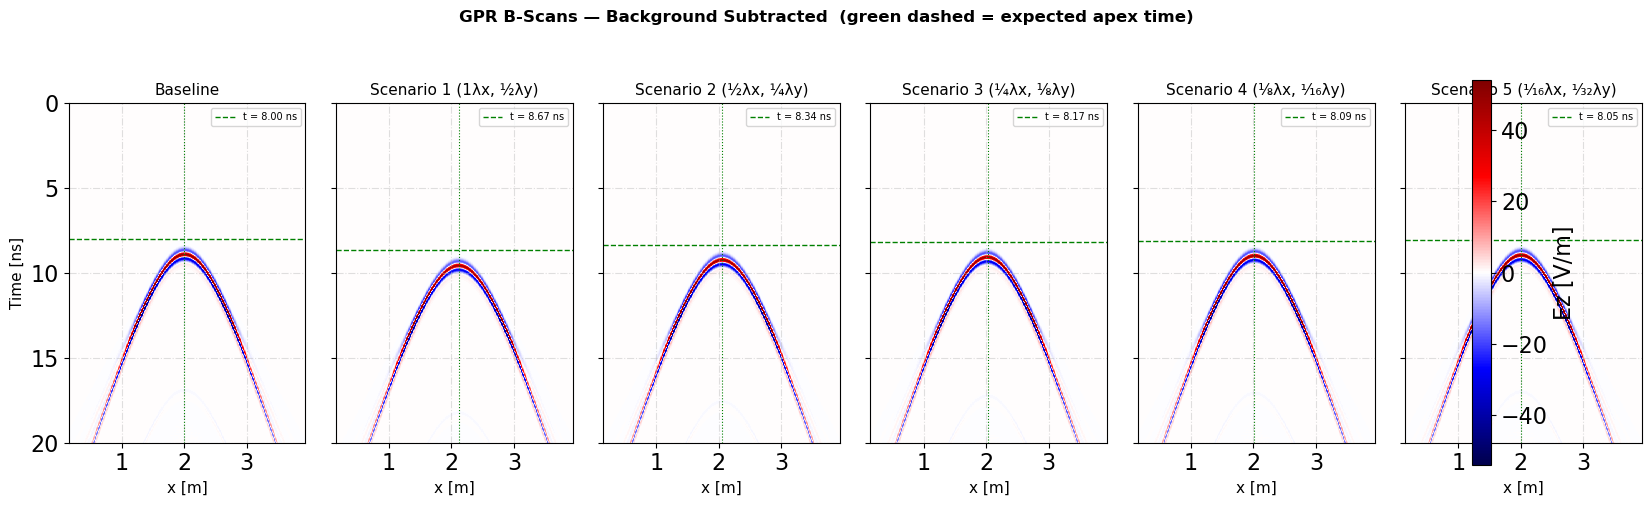

In [11]:
def _apex_marker(ax, i):
    ax.axhline(t_apex[i], color='green', linestyle='--', linewidth=1,
               label=f't = {t_apex[i]:.2f} ns')
    ax.axvline(x_all[i], color='green', linestyle=':', linewidth=0.8)
    ax.legend(fontsize=7, loc='upper right')

fig, axes = plot_bscan_grid(
    data_static, x_traces, time_ns,
    title='GPR B-Scans — Background Subtracted  (green dashed = expected apex time)',
    markers=[_apex_marker] * len(data_static),
)
plt.show()


Create Noisy Data

In [12]:
# ── Apply the fitted Laplace noise model to every background-subtracted B-scan ──
# The Laplace fit (loc/scale) was estimated from the real, fully-processed data
# pipeline ('Spherical Gain' stage), whose amplitudes are ~4 orders of magnitude
# larger than these synthetic Ez B-scans. We keep the Laplace *shape* (loc=0,
# heavier tails than Gaussian) but rescale it so its std is 10% of each B-scan's
# own signal std — a light, realistic noise level rather than the raw fitted scale.
NOISE_LEVEL = 0.1   # target noise std as a fraction of each B-scan's signal std
rng = np.random.default_rng(0)

outputs_noisy = []
for raw in outputs_static:
    target_std    = NOISE_LEVEL * raw.std()
    scaled_scale  = target_std / np.sqrt(2)   # Var(Laplace) = 2 * scale**2
    synthetic_noise = stats.laplace.rvs(
        loc=noise_model_pre_gain['loc'], scale=scaled_scale,
        size=raw.shape, random_state=rng,
    )
    outputs_noisy.append(raw + synthetic_noise)

data_noisy = list(zip(labels_all, outputs_noisy))

print(f"Applied Laplace noise (shape from '{noise_model_pre_gain['stage']}' fit, "
      f"rescaled to {NOISE_LEVEL:.0%} of signal std) to {len(outputs_noisy)} B-scans")


Applied Laplace noise (shape from '7 Constant Velocity' fit, rescaled to 10% of signal std) to 6 B-scans


  [saved] Diagonal_TimeLapse_Study\General\DTL_005_GPR_B-Scans__With_Synthetic_Laplace_Noise_10_of_signal_std.png


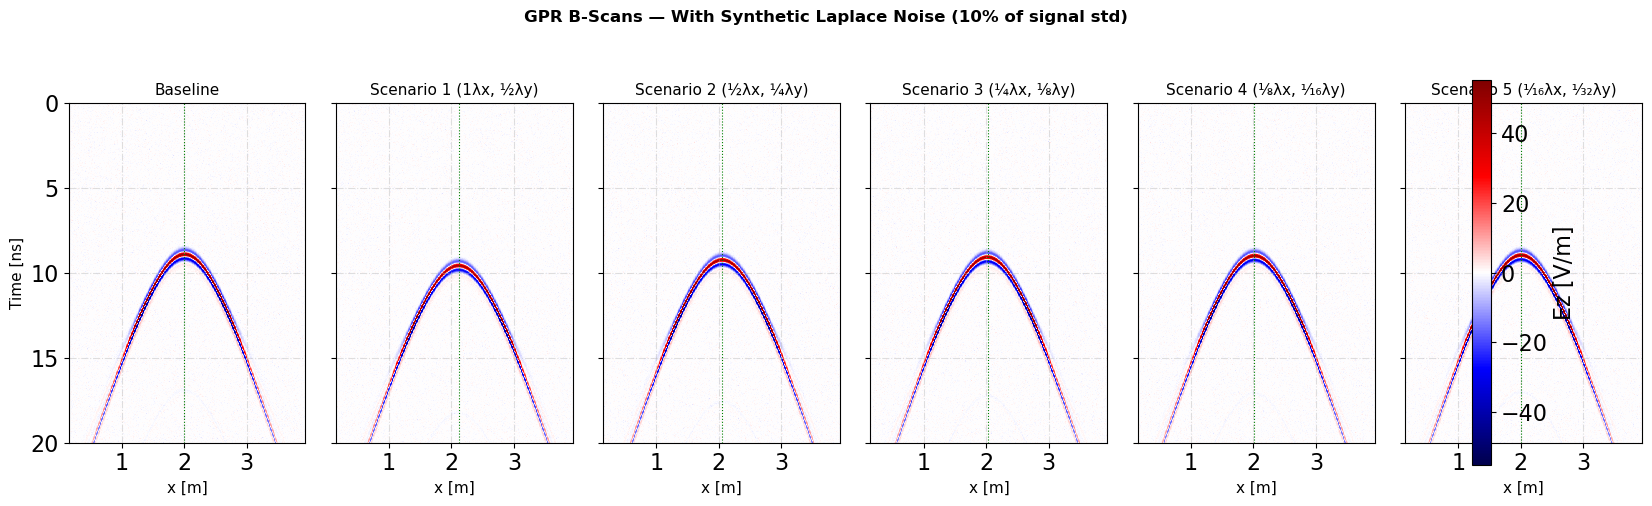

In [13]:
def _apex_marker(ax, i):
    ax.axvline(x_all[i], color='green', linestyle=':', linewidth=0.8)

fig, axes = plot_bscan_grid(
    data_noisy, x_traces, time_ns,
    title='GPR B-Scans — With Synthetic Laplace Noise (10% of signal std)',
    markers=[_apex_marker] * len(data_noisy),
)
plt.show()


  [saved] Diagonal_TimeLapse_Study\General\DTL_006_B-scan_Frequency_Spectra__Clean_vs_Noisy____f_c15_GHz.png


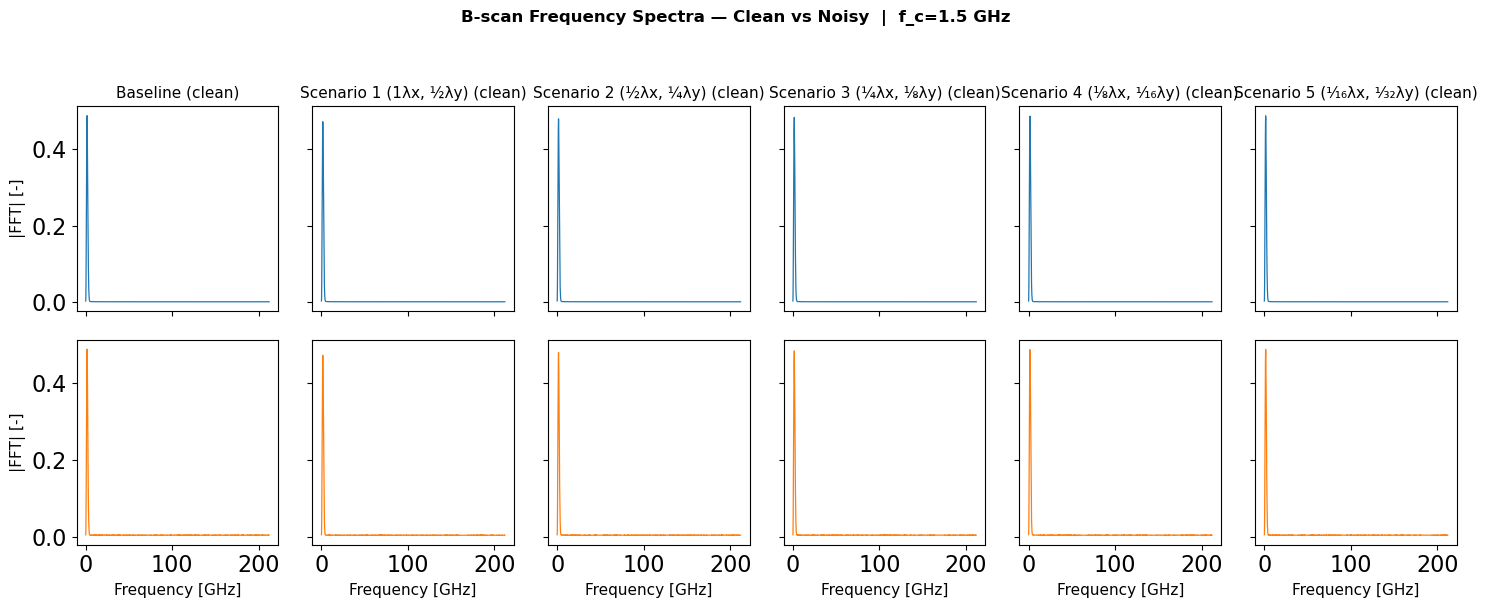

In [14]:
# -- Frequency spectra: clean vs noisy B-scans -----------------------------------
freqs_ghz = np.fft.rfftfreq(n_t, d=dt_ns)

spectra_clean = [(f'{label} (clean)', np.abs(np.fft.rfft(d, axis=0, norm='forward')).mean(axis=1))
                  for label, d in data_static]
spectra_noisy = [(f'{label} (noisy)', np.abs(np.fft.rfft(d, axis=0, norm='forward')).mean(axis=1))
                  for label, d in data_noisy]

fig, axes = plot_spectrum_grid(
    [spectra_clean, spectra_noisy], freqs_ghz,
    title=f'B-scan Frequency Spectra — Clean vs Noisy  |  f_c={f_c_GHz} GHz',
    row_colors=('C0', 'C1'),
)
plt.show()


# Saving the Data

In [ ]:
# ── Save non-migrated (raw, background-subtracted) B-scan data ────────────────
# Stacks all 6 scenarios (Baseline + 5 diagonal shifts) from data_static into a
# single array and saves to static_results.npz.
# Index 0 = Baseline, indices 1-5 = scenario 1-5.

static_all = np.stack([d.astype(float) for _, d in data_static], axis=0)  # (6, n_t, n_traces)

save_path_static = STUDY_ROOT / "static_results.npz"

np.savez_compressed(
    save_path_static,
    data_static       = static_all,                                     # (6, n_t, n_traces)
    scenarios         = np.array(labels_all, dtype="U30"),               # (6,)  Baseline + 5 shifts
    shift_lambda_x    = np.array([0] + shifts_lambda_x),                 # (6,)  0 = baseline
    shift_lambda_y    = np.array([0] + shifts_lambda_y),
    x_traces          = x_traces,
    time_ns           = time_ns,
    dt                = np.float64(dt),
    x_scatterers      = np.array(x_all),
    y_scatterers      = np.array(y_all),
    z_depths          = np.array([z_scatterer] + z_depths_shift),
    x_baseline        = np.float64(x_baseline),
    y_baseline        = np.float64(y_baseline),
    z_scatterer       = np.float64(z_scatterer),
    z_top             = np.float64(z_top),
)

print(f"Saved → {save_path_static}")
print(f"\nStacked array  (n_scenarios={static_all.shape[0]}, n_t={static_all.shape[1]}, n_tr={static_all.shape[2]}):")
print(f"  data_static   {static_all.shape}")
print(f"\nUsage example:")
print(f"  d = np.load(str(STUDY_ROOT / 'static_results.npz'), allow_pickle=False)")
print(f"  d['data_static'][0]   # Baseline B-scan → shape (n_t, n_tr)")
print(f"  d['data_static'][3]   # Scenario 3 B-scan → shape (n_t, n_tr)")


# Kirchhoff Migration

Delay-and-sum migration via the **PyLops zero-offset Kirchhoff operator**.


## Tapering & t0 Shift

Two pre-processing steps applied to every B-scan before migration:

| Step | Purpose |
|---|---|
| End taper (half-cosine) | Suppress ringing from late-time hyperbola tails |
| Exponential decay taper | Down-weight late, noisy arrivals |
| t0 roll | Compensate for Ricker wavelet peak delay so zero-offset apex aligns with t=0 |


In [15]:
import sys, pathlib
_here = pathlib.Path.cwd()
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))
from helper_functions.migration import (PylopsKirchoffMigration, gazdag_migration,
                                        write_backprop_files, dispersion_limited_cutoff,
                                        lowpass_filter_excitation)


  [saved] Diagonal_TimeLapse_Study\General\DTL_015_Effect_of_Tapering_and_t0_Shift__Scenario_1_dataset_single_t.png


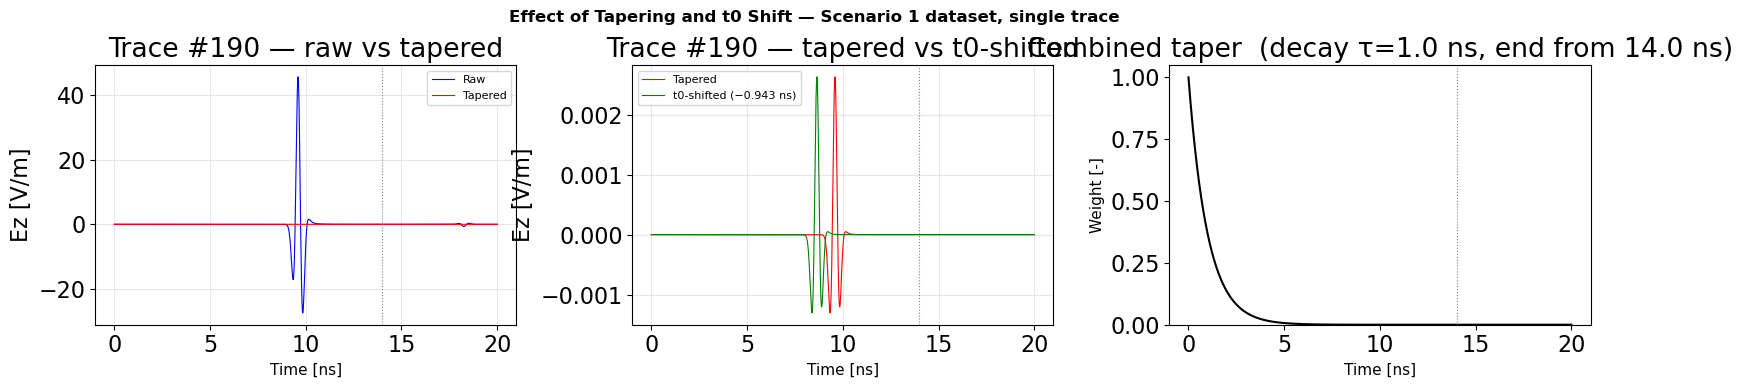

  [saved] Diagonal_TimeLapse_Study\General\DTL_016_B-scan_effect_of_tapering_and_t0_shift__Scenario_1_dataset.png


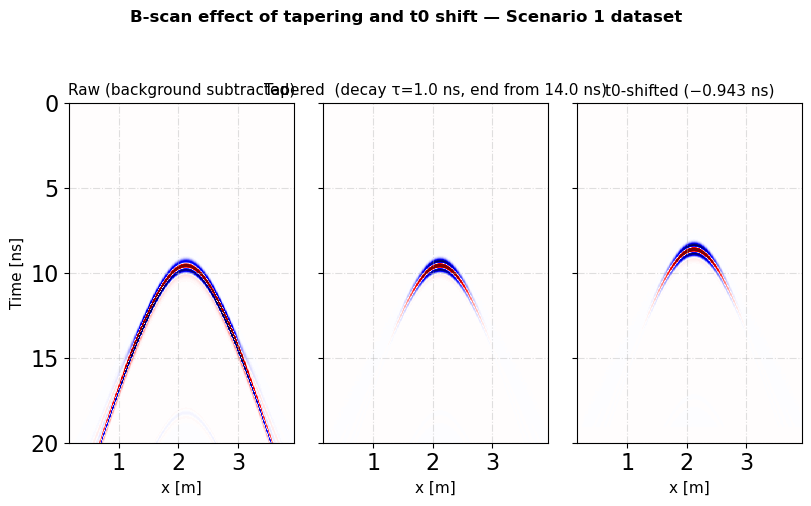

In [22]:
# ── Taper & t0-shift parameters ────────────────────────────────────────────
taper_end_ns   = 14.0   # cosine ramp onset [ns]
taper_decay_ns = 1.0    # exponential decay time constant [ns]
ANGLE_AP       = 40     # Kirchhoff aperture half-angle [degrees]

# ── Functions ───────────────────────────────────────────────────────────────
def make_end_taper(n_samples, taper_samples):
    win = np.ones(n_samples)
    if taper_samples > 0:
        ramp = 0.5 * (1 + np.cos(np.pi * np.arange(taper_samples) / taper_samples))
        win[-taper_samples:] = ramp
    return win

def make_decay_taper(time_ns, tau_ns):
    return np.exp(-time_ns / tau_ns)

def preprocess(data_nt_ntr, dt_ns, t0_ns, time_ns):
    bscan   = data_nt_ntr.T.copy()
    n_t     = bscan.shape[1]
    w_end   = make_end_taper(n_t, int(round(taper_end_ns / dt_ns)))
    w_decay = make_decay_taper(time_ns, taper_decay_ns)
    tapered = bscan * (w_end * w_decay)[np.newaxis, :]
    t0_samp = int(round(t0_ns / dt_ns))
    shifted = np.roll(tapered, -t0_samp, axis=1)
    shifted[:, -t0_samp:] = 0.0
    return tapered, shifted

# ── Visualise effect on the Scenario 1 dataset ─────────────────────────────
_demo = outputs_static[1]    # (n_t, n_tr) - Scenario 1 background-subtracted
_raw_tr, _shifted = preprocess(_demo, dt_ns, t0_ns, time_ns)
_tapered = _raw_tr

w_end_vis   = make_end_taper(n_t, int(round(taper_end_ns   / dt_ns)))
w_decay_vis = make_decay_taper(time_ns, taper_decay_ns)
taper_combined = w_end_vis * w_decay_vis

mid_tr = n_traces // 2

fig, axes = plot_trace_comparison(
    traces=[
        [('Raw', _demo[:, mid_tr], 'b'), ('Tapered', _tapered[mid_tr], 'r')],
        [('Tapered', _tapered[mid_tr], 'r'),
         (f't0-shifted (−{t0_ns:.3f} ns)', _shifted[mid_tr], 'g')],
        [],
    ],
    time_ns=time_ns,
    title='Effect of Tapering and t0 Shift — Scenario 1 dataset, single trace',
    taper_curve=taper_combined,
    vline=taper_end_ns,
)
axes[0].set(ylabel='Ez [V/m]', title=f'Trace #{mid_tr} — raw vs tapered')
axes[1].set(ylabel='Ez [V/m]', title=f'Trace #{mid_tr} — tapered vs t0-shifted')
axes[2].set_title(f'Combined taper  (decay τ={taper_decay_ns} ns, end from {taper_end_ns} ns)')
axes[0].grid(alpha=0.3); axes[1].grid(alpha=0.3)
plt.show()

data_taper_bscans = [
    ('Raw (background subtracted)', _demo),
    (f'Tapered  (decay τ={taper_decay_ns} ns, end from {taper_end_ns} ns)', _tapered.T),
    (f't0-shifted (−{t0_ns:.3f} ns)', _shifted.T),
]
fig, axes = plot_bscan_grid(
    data_taper_bscans, x_traces, time_ns, ncols=3,
    shared_colorbar=False, vmax_headroom=0.5,
    title='B-scan effect of tapering and t0 shift — Scenario 1 dataset',
)
plt.show()


In [ ]:
# ── Kirchhoff migration on all 6 datasets ──────────────────────────────────
migrated = {}
z_depths_all = [z_scatterer] + z_depths_shift   # depth of scatterer per scenario

for label, raw in zip(labels_all, outputs_static):
    _, shifted = preprocess(raw, dt_ns, t0_ns, time_ns)
    print(f'[{label}] Running Kirchhoff ...', end=' ', flush=True)
    t0 = _time.perf_counter()
    img = PylopsKirchoffMigration(
        shifted, time_ns, x_traces, v_ice, z_img,
        f0=f_c_GHz, angleaperture=ANGLE_AP
    )
    print(f'{_time.perf_counter()-t0:.1f} s  shape={img.shape}')
    migrated[label] = img


  [saved] Diagonal_TimeLapse_Study\Kirchhoff\DTL_007_Kirchhoff_Migration__All_6_Datasets____f_c15_GHz____aperture.png


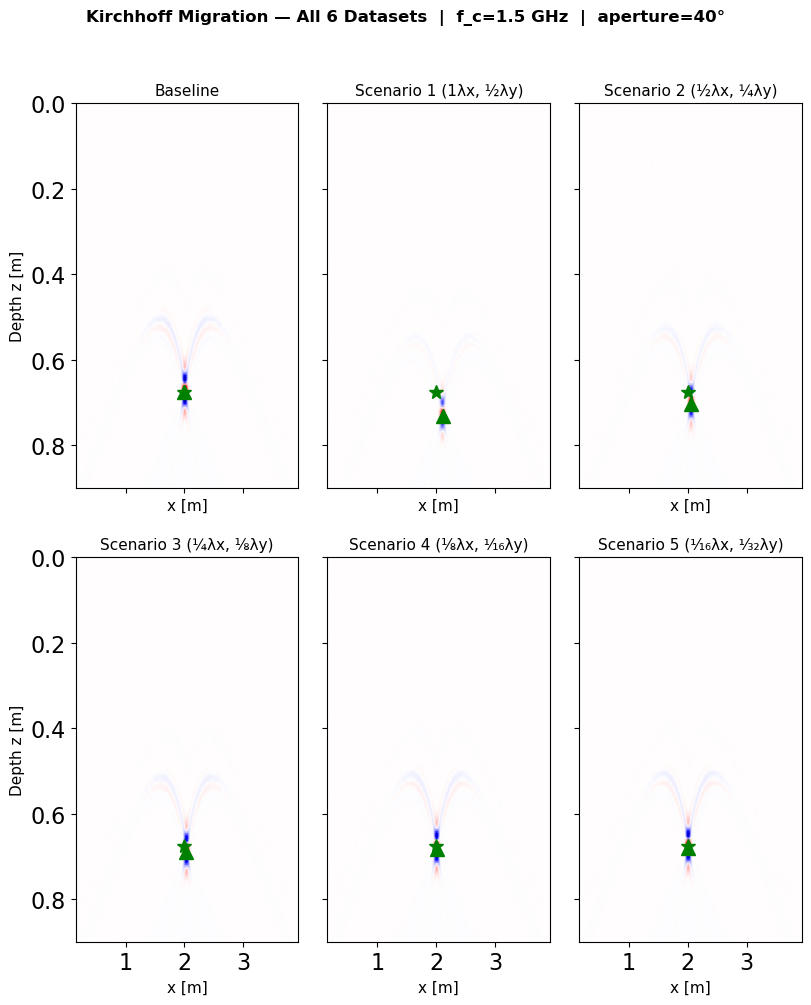

  [saved] Diagonal_TimeLapse_Study\Kirchhoff\DTL_008_Kirchhoff_Migration_zoomed____f_c15_GHz____aperture40.png


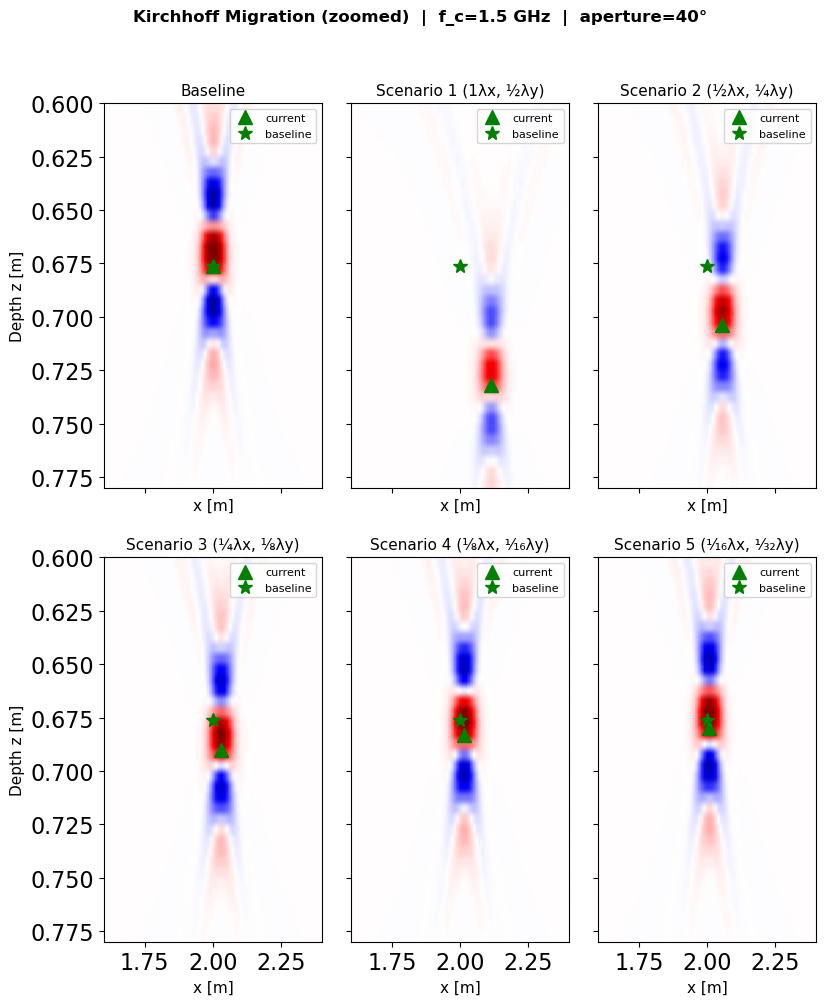

In [16]:
# ── Plot: full extent ──────────────────────────────────────────────────────
extent_mig = [x_traces[0], x_traces[-1], z_img[-1], z_img[0]]
_migrated_baseline_xy = (x_all[0], z_depths_all[0])

fig, axes = plot_migrated_grid(
    migrated, extent_mig,
    title=f'Kirchhoff Migration — All 6 Datasets  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP}°',
    ncols=3,
    marker_x=lambda i, label: x_all[i], marker_z=lambda i, label: z_depths_all[i],
)
_finish_markers(axes, _migrated_baseline_xy, legend='none')
plt.show()

# ── Plot: zoomed on scatterer region ────────────────────────────────────────
fig, axes = plot_migrated_grid(
    migrated, extent_mig,
    title=f'Kirchhoff Migration (zoomed)  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP}°',
    ncols=3,
    marker_x=lambda i, label: x_all[i], marker_z=lambda i, label: z_depths_all[i],
    zooms=[((1.6, 2.4), (0.78, 0.60), '')],
)[0]
_finish_markers(axes, _migrated_baseline_xy, legend='all')
plt.show()


  [saved] Diagonal_TimeLapse_Study\Kirchhoff\DTL_009_Kirchhoff_Migration__TimeLapse_Differences_migrated__migrate.png


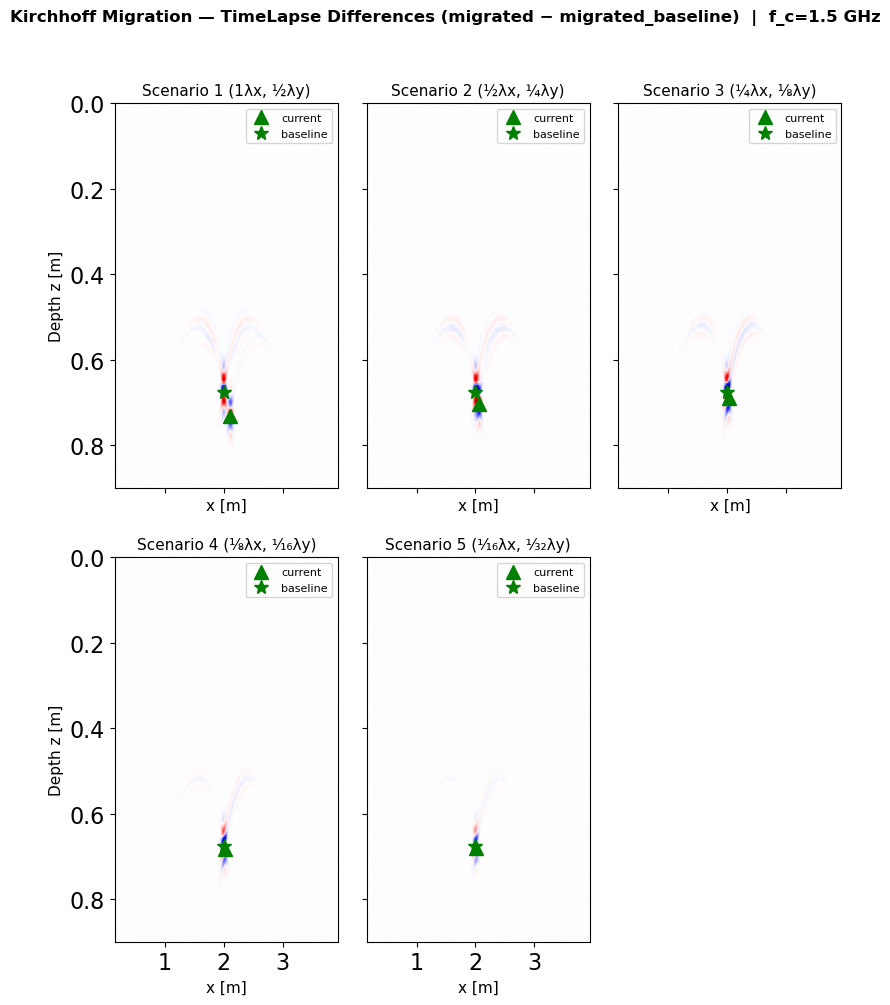

  [saved] Diagonal_TimeLapse_Study\Kirchhoff\DTL_010_Kirchhoff_Migration__TimeLapse_Differences_zoomed.png


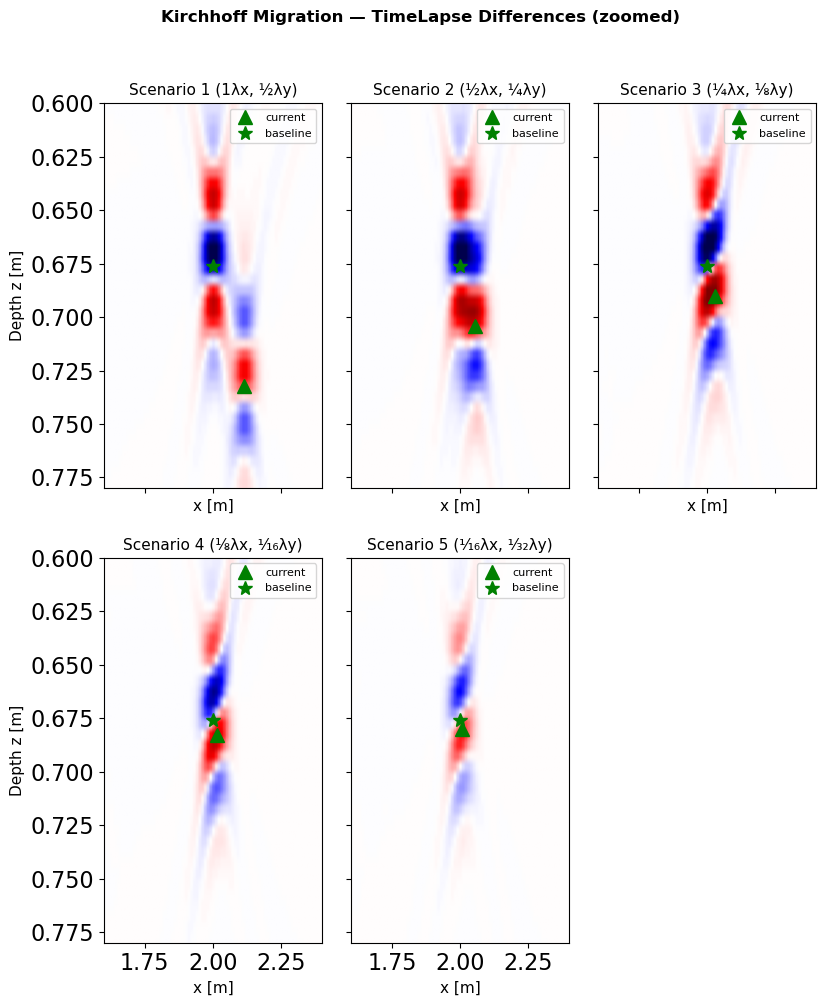

In [17]:
# ── Kirchhoff timelapse differences (migrated − migrated_baseline) ─────────
migrated_diff = {label: migrated[label] - migrated['Baseline'] for label in labels}

fig, axes = plot_migrated_grid(
    migrated_diff, extent_mig,
    title=f'Kirchhoff Migration — TimeLapse Differences (migrated − migrated_baseline)  |  f_c={f_c_GHz} GHz',
    ncols=3,
    marker_x=lambda i, label: x_all[labels.index(label) + 1],
    marker_z=lambda i, label: z_depths_all[labels.index(label) + 1],
)
_finish_markers(axes, _migrated_baseline_xy, legend='all')
plt.show()

# ── Zoomed ─────────────────────────────────────────────────────────────────
fig, axes = plot_migrated_grid(
    migrated_diff, extent_mig,
    title='Kirchhoff Migration — TimeLapse Differences (zoomed)',
    ncols=3,
    marker_x=lambda i, label: x_all[labels.index(label) + 1],
    marker_z=lambda i, label: z_depths_all[labels.index(label) + 1],
    zooms=[((1.6, 2.4), (0.78, 0.60), '')],
)[0]
_finish_markers(axes, _migrated_baseline_xy, legend='all')
plt.show()


# Gazdag Phase-Shift Migration

f-k domain migration via **PyLops `PhaseShift`** downward continuation.


In [18]:
import pylops


## Run Migration on All Datasets

In [ ]:
# ── Gazdag phase-shift migration on all 6 datasets ─────────────────────────
migrated_gz = {}

for label, raw in zip(labels_all, outputs_static):
    _, shifted = preprocess(raw, dt_ns, t0_ns, time_ns)
    print(f'[{label}] Running Gazdag ...', flush=True)
    t0 = _time.perf_counter()
    img = gazdag_migration(
        shifted.T,       # (n_t, n_tr) – time first
        x_traces, time_ns, z_img, v_ice
    )
    print(f'  Done in {_time.perf_counter()-t0:.1f} s  shape={img.shape}')
    migrated_gz[label] = img


  [saved] Diagonal_TimeLapse_Study\Gazdag\DTL_011_Gazdag_Phase-Shift_Migration__All_6_Datasets____f_c15_GHz.png


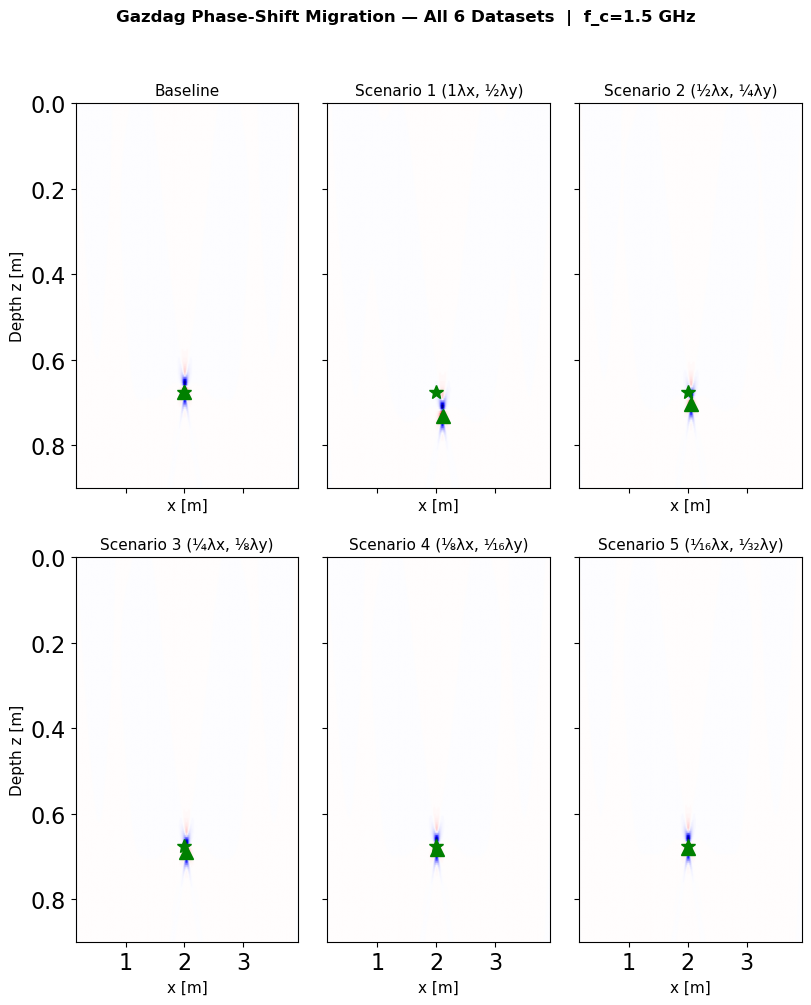

  [saved] Diagonal_TimeLapse_Study\Gazdag\DTL_012_Gazdag_Phase-Shift_Migration_zoomed____f_c15_GHz.png


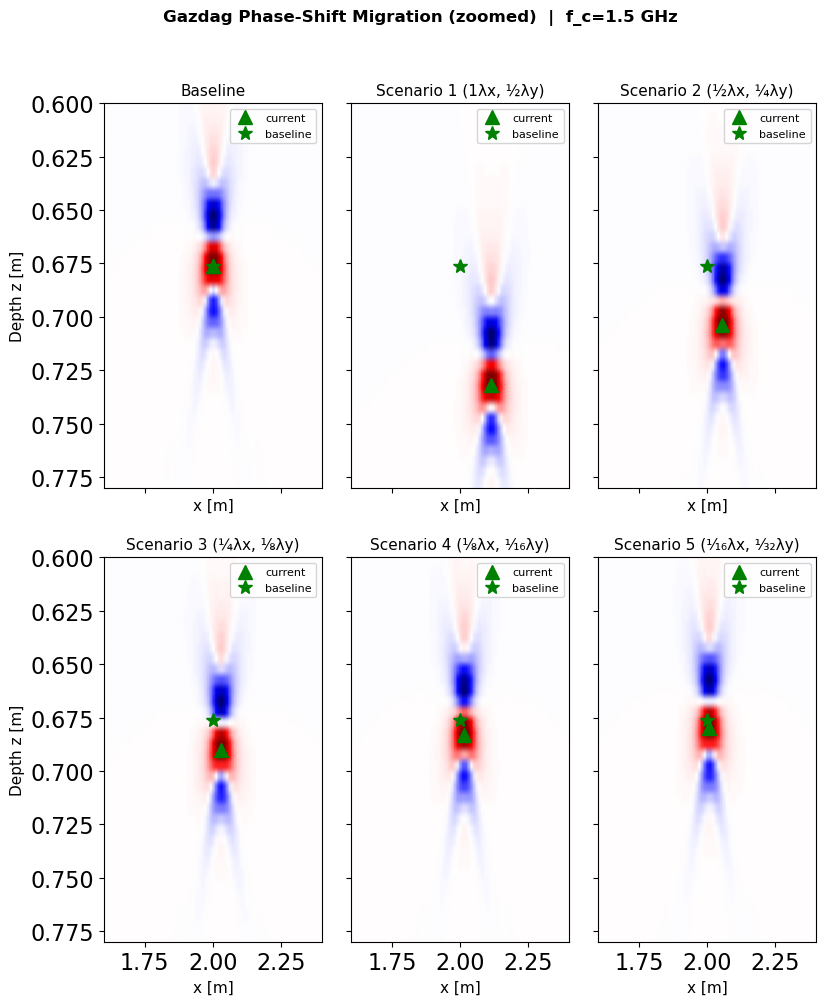

In [19]:
# ── Plot: full extent ────────────────────────────────────────────────────────
fig, axes = plot_migrated_grid(
    migrated_gz, extent_mig,
    title=f'Gazdag Phase-Shift Migration — All 6 Datasets  |  f_c={f_c_GHz} GHz',
    ncols=3,
    marker_x=lambda i, label: x_all[i], marker_z=lambda i, label: z_depths_all[i],
)
_finish_markers(axes, _migrated_baseline_xy, legend='none')
plt.show()

# ── Plot: zoomed ─────────────────────────────────────────────────────────
fig, axes = plot_migrated_grid(
    migrated_gz, extent_mig,
    title=f'Gazdag Phase-Shift Migration (zoomed)  |  f_c={f_c_GHz} GHz',
    ncols=3,
    marker_x=lambda i, label: x_all[i], marker_z=lambda i, label: z_depths_all[i],
    zooms=[((1.6, 2.4), (0.78, 0.60), '')],
)[0]
_finish_markers(axes, _migrated_baseline_xy, legend='all')
plt.show()


  [saved] Diagonal_TimeLapse_Study\Gazdag\DTL_013_Gazdag_Migration__TimeLapse_Differences_migrated__migrated_b.png


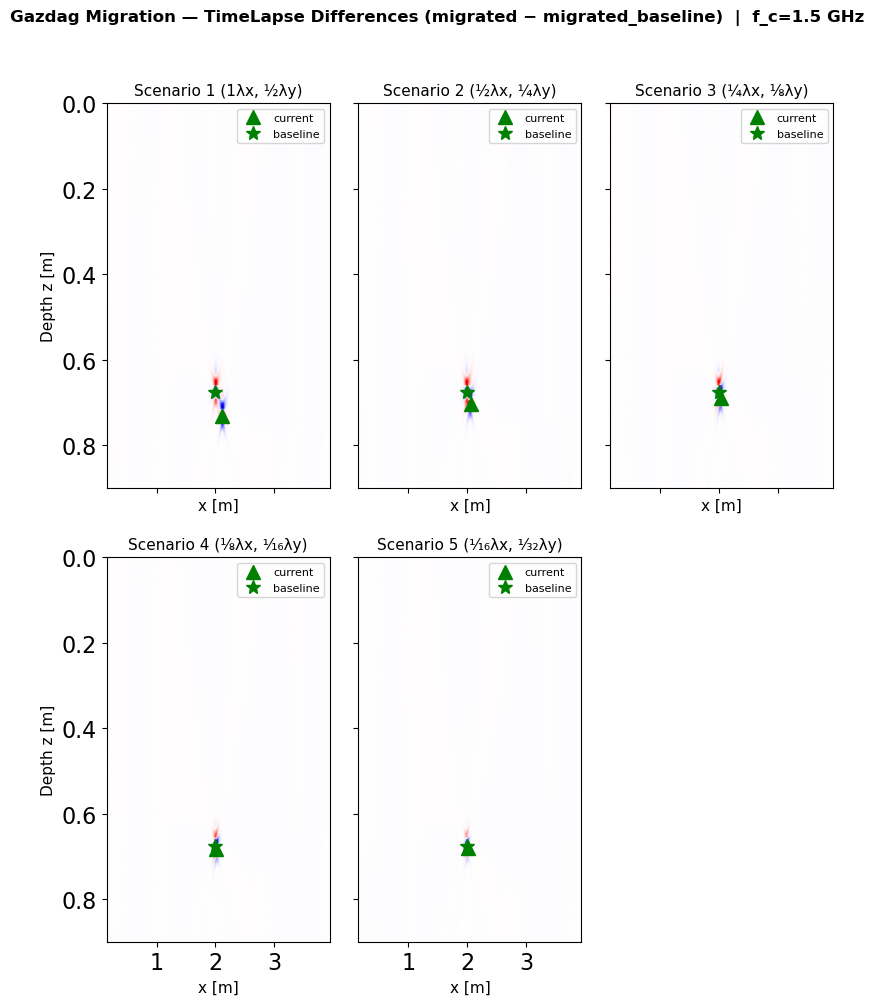

  [saved] Diagonal_TimeLapse_Study\Gazdag\DTL_014_Gazdag_Migration__TimeLapse_Differences_zoomed.png


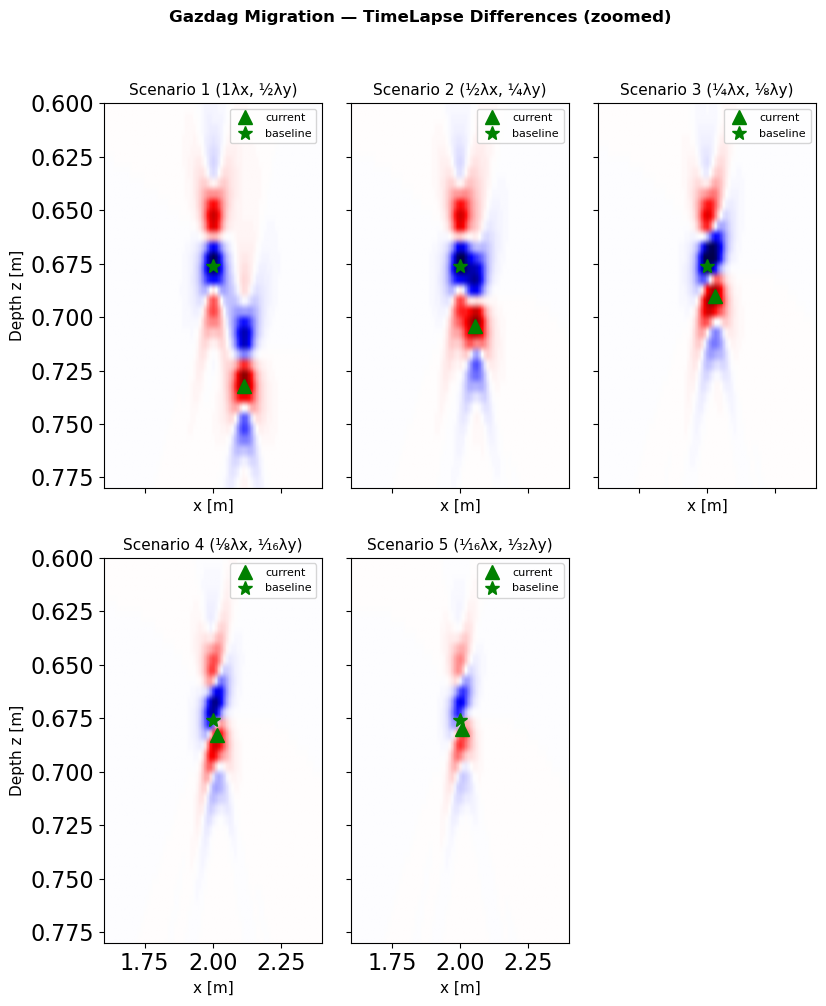

In [20]:
# ── Gazdag timelapse differences ──────────────────────────────────────────
migrated_gz_diff = {label: migrated_gz[label] - migrated_gz['Baseline'] for label in labels}

fig, axes = plot_migrated_grid(
    migrated_gz_diff, extent_mig,
    title=f'Gazdag Migration — TimeLapse Differences (migrated − migrated_baseline)  |  f_c={f_c_GHz} GHz',
    ncols=3,
    marker_x=lambda i, label: x_all[labels.index(label) + 1],
    marker_z=lambda i, label: z_depths_all[labels.index(label) + 1],
)
_finish_markers(axes, _migrated_baseline_xy, legend='all')
plt.show()

# ── Zoomed ─────────────────────────────────────────────────────────────────
fig, axes = plot_migrated_grid(
    migrated_gz_diff, extent_mig,
    title='Gazdag Migration — TimeLapse Differences (zoomed)',
    ncols=3,
    marker_x=lambda i, label: x_all[labels.index(label) + 1],
    marker_z=lambda i, label: z_depths_all[labels.index(label) + 1],
    zooms=[((1.6, 2.4), (0.78, 0.60), '')],
)[0]
_finish_markers(axes, _migrated_baseline_xy, legend='all')
plt.show()


# Back-Propagation Migration

Time-reversal migration: re-inject the time-reversed, normalised B-scan as sources at the receiver positions and let gprMax propagate the wavefield backward in time.


In [23]:
# -- Back-propagation parameters ------------------------------------------
STRIDE   = 1    # use every Nth trace
N_SNAP   = 30   # number of snapshots in the focus window
SNAP_WIN = 1.0  # [ns] window before focus time

# Some lambda fractions inject sub-wavelength-spaced sources whose time-
# reversed wavefield carries spectral content above gprMax's numerical-
# dispersion limit (cells/wavelength), causing a 'Non-physical wave
# propagation' error. Low-pass filter each excitation file right after
# writing it so every .in file is runnable. eps_r*4 / dx=0.001 mirror the
# half-velocity material and grid hardcoded in write_backprop_files() --
# see helper_functions/migration.py.
cutoff_hz = dispersion_limited_cutoff(eps_r=4.0 * eps_r, dx=0.001)

# -- Generate files for all 6 datasets --------------------------------------
print(f'Back-propagation file generation  (stride={STRIDE}, {N_SNAP} snapshots)' + chr(10))
bp_paths = {}
for label, slug, raw in zip(labels_all, slugs_all, outputs_static):
    tapered, _ = preprocess(raw, dt_ns, t0_ns, time_ns)
    in_path, n_src, n_snaps, t_focus = write_backprop_files(
        STUDY_ROOT, label, slug, tapered, dt_ns, x_traces,
        t0_ns, eps_r, v_ice, stride=STRIDE, n_snap=N_SNAP, snap_win=SNAP_WIN
    )
    lowpass_filter_excitation(in_path.parent / 'excitation.txt', cutoff_hz, edge_exclude = 2)
    bp_paths[label] = in_path
    exc_mb = (in_path.parent / 'excitation.txt').stat().st_size / 1e6
    print(f'  [{label}]  {n_src} sources  |  {n_snaps} snapshots  |  '
          f'focus={t_focus:.2f} ns  |  excitation={exc_mb:.1f} MB  |  '
          f'low-pass={cutoff_hz/1e9:.1f} GHz')
    print(f'           {in_path}')


Back-propagation file generation  (stride=1, 30 snapshots)

  [Baseline]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=44.1 MB  |  low-pass=19.7 GHz
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\diagonal_timelapse_study\backprop\baseline\backprop_baseline.in
  [Scenario 1 (1λx, ½λy)]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=44.2 MB  |  low-pass=19.7 GHz
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\diagonal_timelapse_study\backprop\scenario1\backprop_scenario1.in
  [Scenario 2 (½λx, ¼λy)]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=44.1 MB  |  low-pass=19.7 GHz
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\diagonal_timelapse_study\backprop\scenario2\backprop_scenario2.in
  [Scenario 3 (¼λx, ⅛λy)]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=44.1 MB  |  low-pass=19.7 GHz
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Noteboo

[Baseline]  29 snaps  |  focus idx=19  t=19.316 ns
[Scenario 1 (1λx, ½λy)]  29 snaps  |  focus idx=19  t=19.316 ns
[Scenario 2 (½λx, ¼λy)]  29 snaps  |  focus idx=19  t=19.316 ns
[Scenario 3 (¼λx, ⅛λy)]  29 snaps  |  focus idx=19  t=19.316 ns
[Scenario 4 (⅛λx, ¹⁄₁₆λy)]  29 snaps  |  focus idx=19  t=19.316 ns
[Scenario 5 (¹⁄₁₆λx, ¹⁄₃₂λy)]  29 snaps  |  focus idx=19  t=19.316 ns
  [saved] Diagonal_TimeLapse_Study\Back-Propagation\DTL_017_Back-Propagation_E__All_6_Datasets____focus_at_1906_ns.png


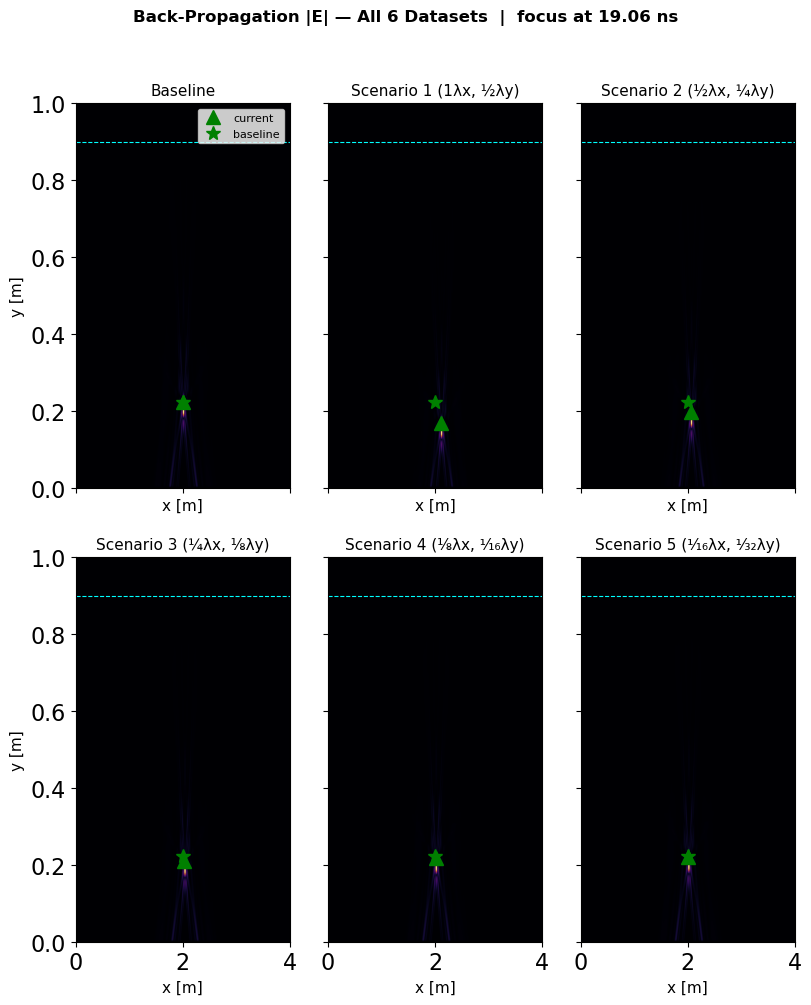

  [saved] Diagonal_TimeLapse_Study\Back-Propagation\DTL_018_Back-Propagation_E_zoomed____focus_at_1906_ns.png


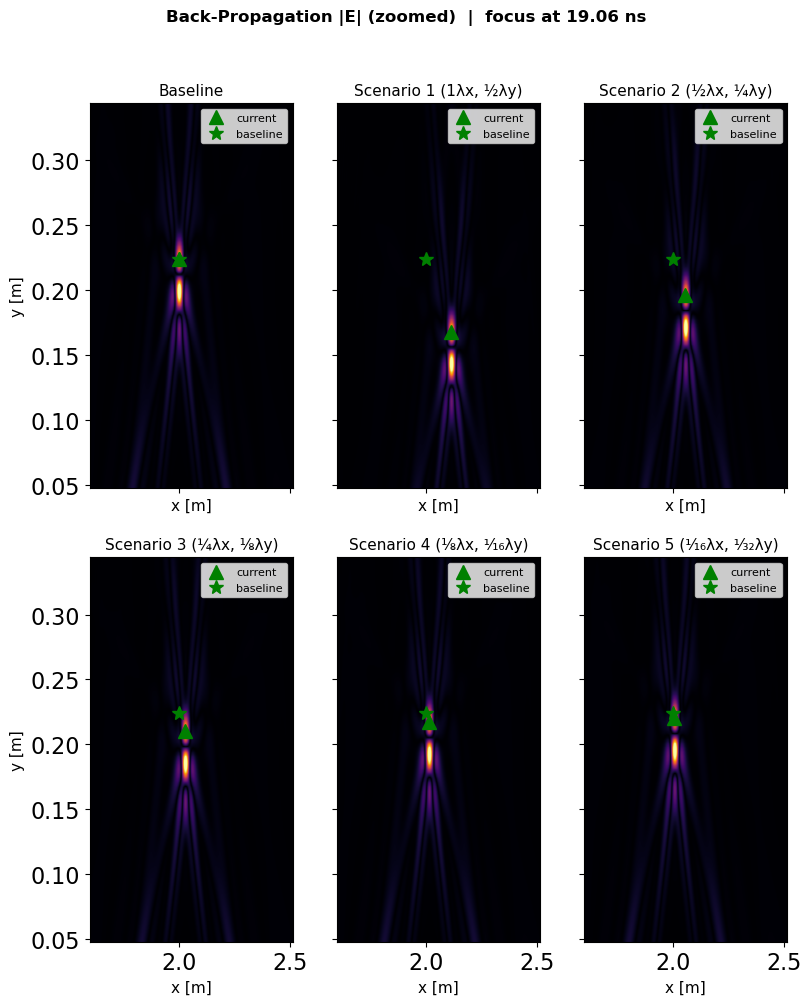

  [saved] Diagonal_TimeLapse_Study\Back-Propagation\DTL_019_Back-Propagation_Ez__All_6_Datasets____focus_at_1906_ns.png


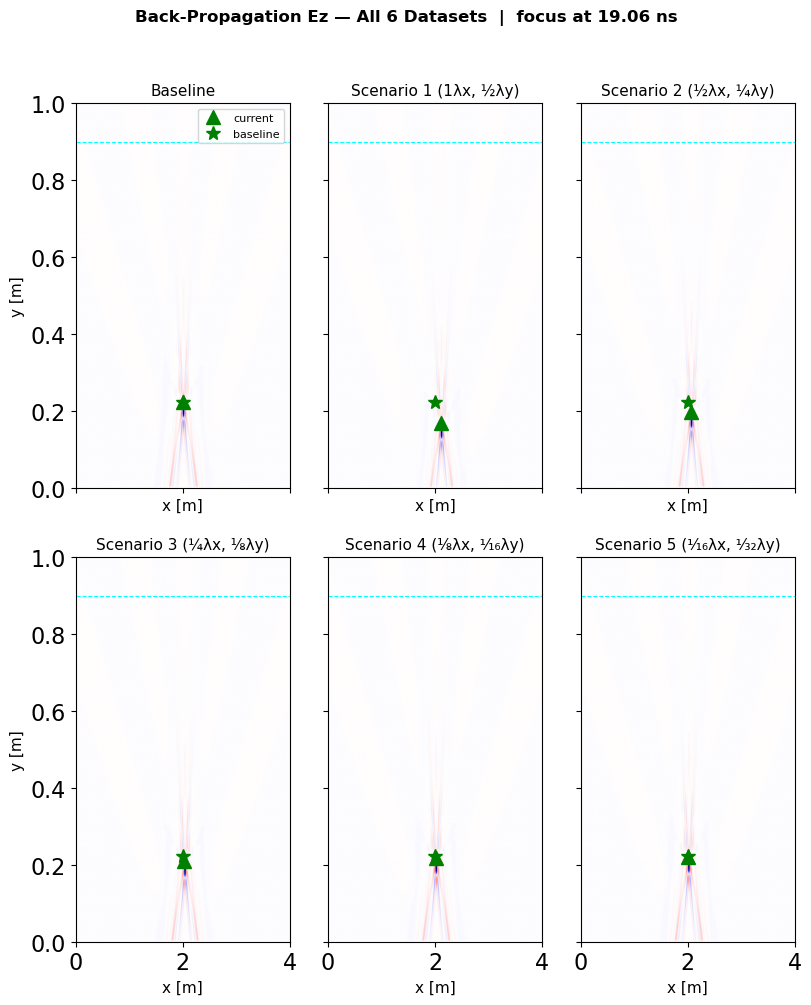

  [saved] Diagonal_TimeLapse_Study\Back-Propagation\DTL_020_Back-Propagation_Ez_zoomed____focus_at_1906_ns.png


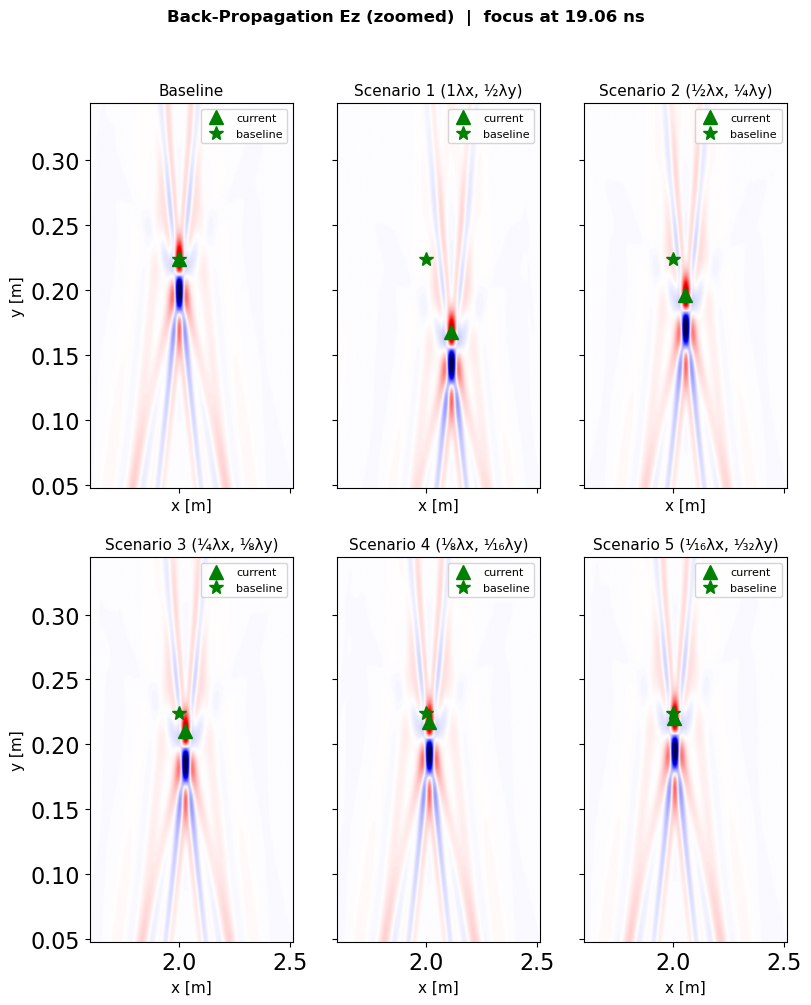

In [24]:
import pyvista

# ── Load focus frame for all 6 datasets ───────────────────────────────────
T_ns_bp    = n_t * dt_ns
t_focus_ns = T_ns_bp - t0_ns
t_start_ns = max(0.0, t_focus_ns - SNAP_WIN)
dt_s       = dt_ns * 1e-9
snap_step_ref = max(1, int((T_ns_bp*1e-9 - t_start_ns*1e-9) / (max(1, N_SNAP - 1) * dt_s)))

focus_frames = {}
for i, (label, slug) in enumerate(zip(labels_all, slugs_all)):
    snap_dir   = STUDY_ROOT / 'backprop' / slug / f'backprop_{slug}_snaps'
    snap_files = sorted(
        snap_dir.glob('bp_snap*.vti'),
        key=lambda p: int(p.stem.replace('bp_snap', ''))
    )
    if not snap_files:
        print(f'[{label}] No snapshots in {snap_dir.name} – skipping')
        continue

    snap_times_ns = t_start_ns + np.arange(len(snap_files)) * snap_step_ref * dt_ns
    idx_focus     = min(int(np.argmin(np.abs(snap_times_ns - t_focus_ns))) + 4,
                        len(snap_files) - 1)

    snaps_mag, snaps_ez = [], []
    for p in snap_files:
        mesh   = pyvista.read(str(p))
        e_data = np.array(mesh['E-field'])
        snaps_mag.append(np.linalg.norm(e_data, axis=1).reshape(1000, 4000))
        snaps_ez.append(e_data[:, 2].reshape(1000, 4000))

    focus_frames[label] = {
        'mag':      np.stack(snaps_mag)[idx_focus],
        'ez':       np.stack(snaps_ez)[idx_focus],
        't_actual': snap_times_ns[idx_focus],
        'i':        i,
    }
    print(f'[{label}]  {len(snap_files)} snaps  |  focus idx={idx_focus}'
          f'  t={focus_frames[label]["t_actual"]:.3f} ns')

extent_full = [0, 4.0, 0, 1]
margin_x    = 0.4
margin_y    = 0.12

# Zoom window centred on the diagonal scatterer path
x_zoom_lo = min(x_all) - margin_x
x_zoom_hi = max(x_all) + margin_x
y_zoom_lo = min(y_all) - margin_y
y_zoom_hi = max(y_all) + margin_y

_bp_baseline_xy = (x_baseline, y_baseline)

def _bp_marker_x(i, label):
    return x_all[focus_frames[label]['i']]

def _bp_marker_y(i, label):
    return y_all[focus_frames[label]['i']]

frames_mag = {label: frame['mag'] for label, frame in focus_frames.items()}
frames_ez  = {label: frame['ez']  for label, frame in focus_frames.items()}

for field, frames_dict, word in [('magnitude', frames_mag, '|E|'), ('signed', frames_ez, 'Ez')]:
    # ── full extent ──────────────────────────────────────────────────────
    fig, axes = plot_wavefield_grid(
        frames_dict, extent_full, field=field,
        title=f'Back-Propagation {word} — All 6 Datasets  |  focus at {t_focus_ns:.2f} ns',
        ncols=3, y_surface=y_surface,
        marker_x=_bp_marker_x, marker_y=_bp_marker_y,
    )
    _finish_markers(axes, _bp_baseline_xy, legend='first')
    plt.show()

    # ── zoomed ──────────────────────────────────────────────────────────
    fig, axes = plot_wavefield_grid(
        frames_dict, extent_full, field=field,
        title=f'Back-Propagation {word} (zoomed)  |  focus at {t_focus_ns:.2f} ns',
        ncols=3,
        marker_x=_bp_marker_x, marker_y=_bp_marker_y,
        zooms=[((x_zoom_lo, x_zoom_hi), (y_zoom_lo, y_zoom_hi), '')],
    )[0]
    _finish_markers(axes, _bp_baseline_xy, legend='all')
    plt.show()


  [saved] Diagonal_TimeLapse_Study\Back-Propagation\DTL_021_Back-Propagation__TimeLapse_Differences_Ez_Ez__Ez_baseline.png


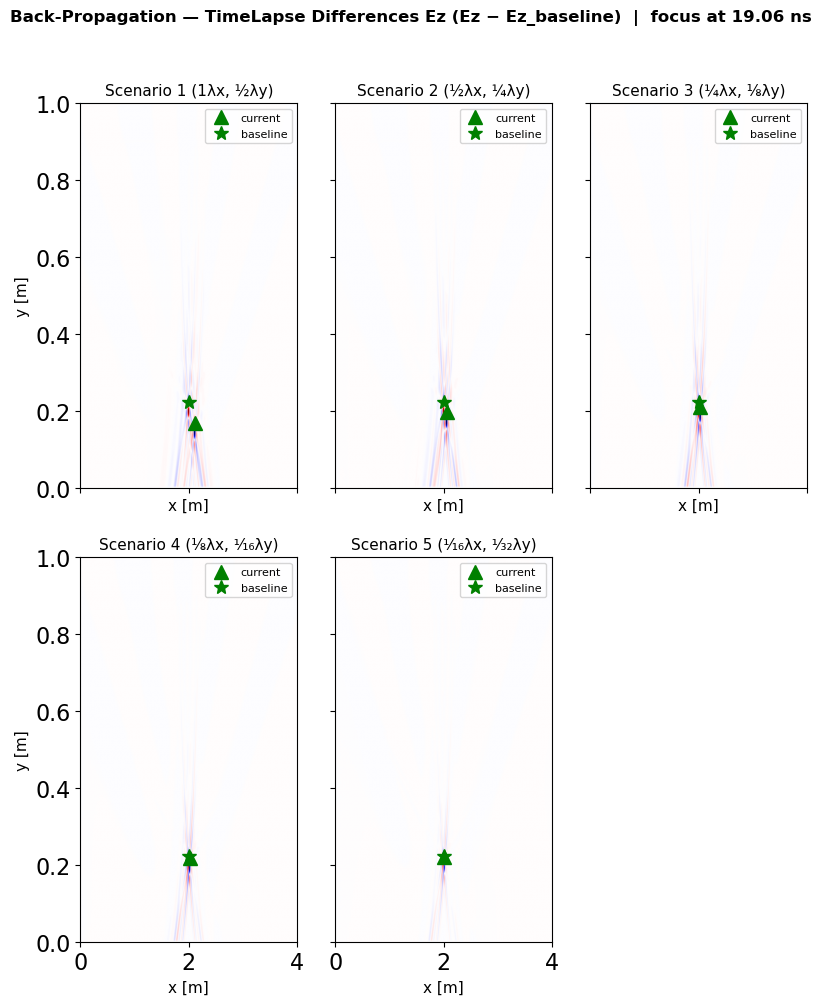

  [saved] Diagonal_TimeLapse_Study\Back-Propagation\DTL_022_Back-Propagation__TimeLapse_Differences_Ez_zoomed.png


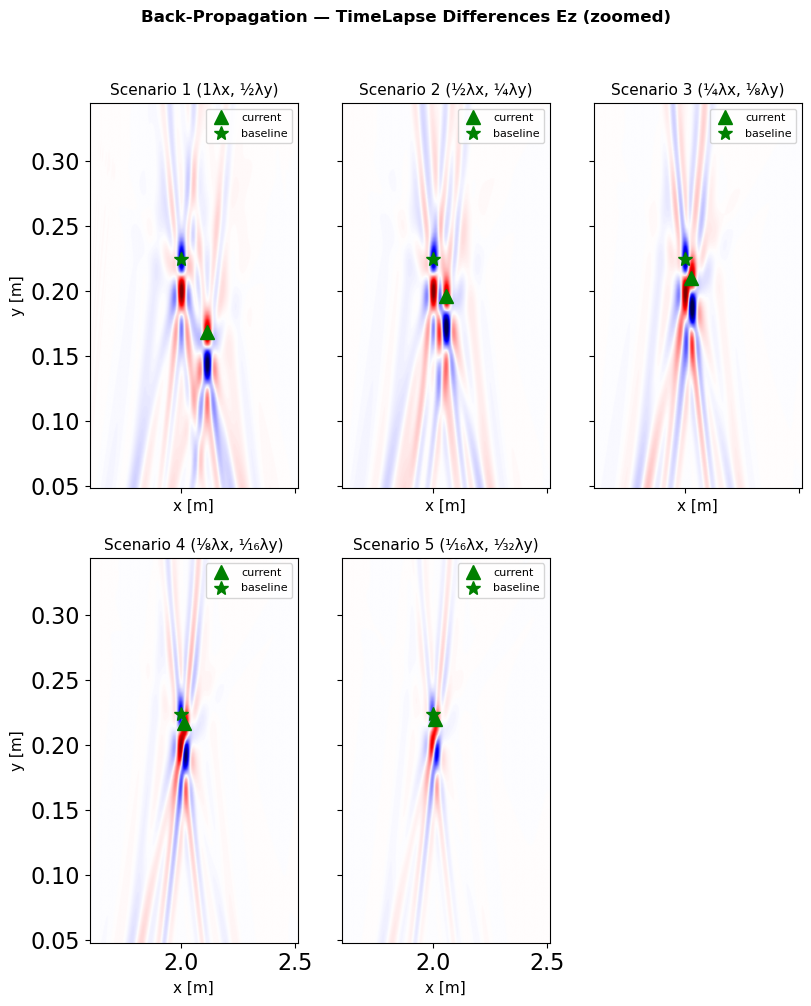

In [25]:
# ── Back-propagation timelapse differences (Ez − Ez_baseline) ────────────
bp_ez_diff = {label: focus_frames[label]['ez'] - focus_frames['Baseline']['ez']
              for label in labels if label in focus_frames}

fig, axes = plot_wavefield_grid(
    bp_ez_diff, extent_full, field='signed',
    title=f'Back-Propagation — TimeLapse Differences Ez (Ez − Ez_baseline)  |  focus at {t_focus_ns:.2f} ns',
    ncols=3,
    marker_x=lambda i, label: x_all[labels.index(label) + 1],
    marker_y=lambda i, label: y_all[labels.index(label) + 1],
)
_finish_markers(axes, _bp_baseline_xy, legend='all')
plt.show()

# ── Zoomed ──────────────────────────────────────────────────────────────────
fig, axes = plot_wavefield_grid(
    bp_ez_diff, extent_full, field='signed',
    title='Back-Propagation — TimeLapse Differences Ez (zoomed)',
    ncols=3,
    marker_x=lambda i, label: x_all[labels.index(label) + 1],
    marker_y=lambda i, label: y_all[labels.index(label) + 1],
    zooms=[((x_zoom_lo, x_zoom_hi), (y_zoom_lo, y_zoom_hi), '')],
)[0]
_finish_markers(axes, _bp_baseline_xy, legend='all')
plt.show()


# Analysis

In [ ]:
from scipy.signal import hilbert as scipy_hilbert
from scipy.interpolate import RegularGridInterpolator

# ── Collect timelapse difference images ────────────────────────────────────
methods = ['Kirchhoff', 'Gazdag', 'Back-prop']
n_m, n_s = len(methods), len(labels)
imgs = [[None] * n_m for _ in range(n_s)]

for i, lbl in enumerate(labels):
    try:    imgs[i][0] = migrated_diff[lbl]
    except (KeyError, NameError): pass
    try:    imgs[i][1] = migrated_gz_diff[lbl]
    except (KeyError, NameError): pass

# Back-propagation – reproject bp_ez_diff to migration grid
x_ax_bp = np.linspace(0, 4.0, 4000)
y_ax_bp = np.linspace(0, 1.0, 1000)
y_mig   = y_surface - z_img
Yq, Xq  = np.meshgrid(y_mig, x_traces, indexing='ij')

for i, lbl in enumerate(labels):
    if lbl not in bp_ez_diff:
        print(f'[{lbl}] bp_ez_diff missing – skipping')
        continue
    interp = RegularGridInterpolator(
        (y_ax_bp, x_ax_bp), bp_ez_diff[lbl],
        method='linear', bounds_error=False, fill_value=0.0
    )
    imgs[i][2] = interp((Yq, Xq))
    print(f'[{lbl}] back-prop diff reprojected  shape={imgs[i][2].shape}')

extent_mig = [x_traces[0], x_traces[-1], z_img[-1], z_img[0]]
xlim = (1.6, 2.4)
ylim = (0.78, 0.60)

fig, axes = plot_method_comparison_grid(
    imgs, extent_mig, methods, labels,
    title=f'Diagonal TimeLapse Migration Comparison — Signed Amplitude  |  f_c={f_c_GHz} GHz',
    envelope=False,
    marker_x=lambda i, j: x_all[i + 1], marker_z=lambda i, j: z_depths_all[i + 1],
    xlim=xlim, ylim=ylim, vmax_percentile=100,
)
# Add the baseline star (plot_method_comparison_grid only draws the
# current/timelapsed marker) and restore this notebook's exact original
# suptitle wording ("shifted", not the helper's hardcoded "timelapsed") so
# the autosaved filename is unchanged.
for i in range(n_s):
    for j in range(n_m):
        if imgs[i][j] is not None:
            axes[i, j].plot(x_baseline, z_depths_all[0], 'g*', ms=10, zorder=5, label='baseline')
fig.suptitle(
    f'Diagonal TimeLapse Migration Comparison — Signed Amplitude  |  f_c={f_c_GHz} GHz  '
    f'|  ★ = baseline,  ▲ = shifted',
    fontsize=13, fontweight='bold', y=1.01
)
plt.show()


In [ ]:
# ── Normalised diagonal PSF of timelapse difference along the motion direction ──
# Because every scenario moves the scatterer by the same (x, y) ratio (2:1 in λ
# units, i.e. Δx = 2·Δz), all scenarios lie on the *same* diagonal line through
# the baseline. We sample each timelapse-difference image along that line,
# parameterised by signed distance s [m] from the baseline position (s = 0 at
# baseline, s > 0 towards the shifted scatterer).
#
# NOTE: plot_psf_grid takes one shared 1-D `axis_values` array for the whole
# grid, but the original per-scenario sampling here was centred on each row's
# *current* (shifted) position and then display-shifted by shift_mag so 0 =
# baseline. Since all scenarios are colinear through the baseline (proven by
# construction above), sampling directly around the *baseline* with the same
# fixed half-window instead reproduces identical values at every shared
# coordinate s (baseline + s*(ux,uz) == current_i + (s - shift_mag_i)*(ux,uz)
# whenever current_i - baseline == shift_mag_i*(ux,uz), true here) while
# making the axis genuinely shared across rows -- required by plot_psf_grid.
# plot_psf_grid also draws both reference lines dashed (no dotted/dashed
# distinction), unlike the original -- caption text below updated to match.

_dx_dir = x_all[1] - x_all[0]
_dz_dir = z_depths_all[1] - z_depths_all[0]
_dir_norm = np.hypot(_dx_dir, _dz_dir)
ux, uz = _dx_dir / _dir_norm, _dz_dir / _dir_norm   # unit vector along motion direction

s_win = 3.0 * wavelength   # half-window along the diagonal direction [m]
s_axis = np.linspace(-s_win, s_win, 400)

def diagonal_profile(img, center_x, center_z, half_len, n_samples=400):
    # Bilinearly sample `img` (n_z, n_x) along the diagonal direction (ux, uz)
    # through (center_x, center_z), returning (s, values).
    interp = RegularGridInterpolator((z_img, x_traces), img, method='linear',
                                      bounds_error=False, fill_value=0.0)
    s  = np.linspace(-half_len, half_len, n_samples)
    xs = center_x + s * ux
    zs = center_z + s * uz
    vals = interp(np.stack([zs, xs], axis=-1))
    return s, vals

profiles          = [[None] * n_m for _ in range(n_s)]
marker_positions  = [[None] * n_m for _ in range(n_s)]

for i, lbl in enumerate(labels):
    shift_mag = np.hypot(x_all[i + 1] - x_baseline, z_depths_all[i + 1] - z_scatterer)
    for j, method in enumerate(methods):
        img = imgs[i][j]
        if img is None:
            continue
        _, profile = diagonal_profile(img, x_baseline, z_scatterer, s_win)
        peak = np.max(np.abs(profile))
        if peak > 0:
            profile = profile / peak
        profiles[i][j] = profile
        marker_positions[i][j] = [0, shift_mag]

fig, axes = plot_psf_grid(
    profiles, s_axis, methods, labels, orientation='vertical',
    marker_positions=marker_positions,
    title=(
        'Normalised Diagonal PSF — TimeLapse Difference Along Motion Direction\n'
        'blue = amplitude  |  red = Hilbert envelope  '
        '|  green dashed = baseline (s=0) & shifted (s=shift magnitude) positions'
    ),
    xlim=(-1.15, 1.4), ylim=(s_win, -s_win),
)
axes[0, 0].legend(fontsize=7, loc='upper right')
plt.show()


# Save Migrated Results as np arrays

In [ ]:
# ── Build structured numpy archive of all migrated difference results ──────
_ref_shape = imgs[0][0].shape   # (n_z, n_x)

def _safe_stack(method_idx):
    planes = []
    for i in range(n_s):
        arr = imgs[i][method_idx]
        planes.append(arr.astype(float) if arr is not None
                      else np.full(_ref_shape, np.nan))
    return np.stack(planes, axis=0)

diff_kirchhoff = _safe_stack(0)   # (5, n_z, n_x)
diff_gazdag    = _safe_stack(1)
diff_backprop  = _safe_stack(2)

save_path = STUDY_ROOT / 'diagonal_difference_migrated_results.npz'

np.savez_compressed(
    save_path,
    kirchhoff_diff    = diff_kirchhoff,
    gazdag_diff       = diff_gazdag,
    backprop_diff     = diff_backprop,
    scenarios         = np.array(labels,  dtype='U30'),
    methods           = np.array(methods, dtype='U20'),
    shift_lambda_x    = np.array(shifts_lambda_x),
    shift_lambda_y    = np.array(shifts_lambda_y),
    x_scatterers      = np.array(x_scatterers_shift),
    y_scatterers      = np.array(y_scatterers_shift),
    z_depths          = np.array(z_depths_shift),
    x_traces          = x_traces,
    z_img             = z_img,
    x_baseline        = np.float64(x_baseline),
    y_baseline        = np.float64(y_baseline),
    z_scatterer       = np.float64(z_scatterer),
    z_top             = np.float64(z_top),
)

print(f'Saved → {save_path}')
print(f'\nDifference arrays  (n_scenarios={n_s}, n_z={_ref_shape[0]}, n_x={_ref_shape[1]}):')
for name, arr in [('kirchhoff_diff', diff_kirchhoff),
                  ('gazdag_diff',    diff_gazdag),
                  ('backprop_diff',  diff_backprop)]:
    absent = int(np.isnan(arr).all(axis=(1, 2)).sum())
    note   = f'  ({absent} scenario(s) absent → NaN)' if absent else ''
    print(f'  {name:<18}  {arr.shape}{note}')


In [ ]:
# ── Save normal (non-difference) migrated results from all methods ─────────
kirchhoff_all = np.stack([migrated[lbl].astype(float)    for lbl in labels_all], axis=0)  # (6, n_z, n_x)
gazdag_all    = np.stack([migrated_gz[lbl].astype(float) for lbl in labels_all], axis=0)

x_ax_bp = np.linspace(0, 4.0, 4000)
y_ax_bp = np.linspace(0, 1.0, 1000)
y_mig   = y_surface - z_img
Yq, Xq  = np.meshgrid(y_mig, x_traces, indexing='ij')

from scipy.interpolate import RegularGridInterpolator as _RGI
backprop_planes = []
for lbl in labels_all:
    if lbl in focus_frames:
        interp = _RGI((y_ax_bp, x_ax_bp), focus_frames[lbl]['ez'],
                      method='linear', bounds_error=False, fill_value=0.0)
        backprop_planes.append(interp((Yq, Xq)).astype(float))
    else:
        backprop_planes.append(np.full((len(z_img), len(x_traces)), np.nan))
        print(f'[{lbl}] focus_frames missing – filled with NaN')
backprop_all = np.stack(backprop_planes, axis=0)   # (6, n_z, n_x)

save_path_mig = STUDY_ROOT / 'diagonal_migrated_results.npz'
np.savez_compressed(
    save_path_mig,
    kirchhoff         = kirchhoff_all,
    gazdag            = gazdag_all,
    backprop          = backprop_all,
    scenarios         = np.array(labels_all, dtype='U30'),
    shift_lambda_x    = np.array([0] + shifts_lambda_x),
    shift_lambda_y    = np.array([0] + shifts_lambda_y),
    x_scatterers      = np.array(x_all),
    y_scatterers      = np.array(y_all),
    z_depths          = np.array([z_scatterer] + z_depths_shift),
    x_baseline        = np.float64(x_baseline),
    y_baseline        = np.float64(y_baseline),
    z_scatterer       = np.float64(z_scatterer),
    z_top             = np.float64(z_top),
)

print(f'Saved → {save_path_mig}')
print(f'\nStacked arrays  (n_scenarios=6, n_z={kirchhoff_all.shape[1]}, n_x={kirchhoff_all.shape[2]}):')
for name, arr in [('kirchhoff', kirchhoff_all), ('gazdag', gazdag_all), ('backprop', backprop_all)]:
    absent = int(np.isnan(arr).all(axis=(1, 2)).sum())
    note   = f'  ({absent} absent → NaN)' if absent else ''
    print(f'  {name:<12}  {arr.shape}{note}')


# Application to Noisy Data

## Save Unmigrated Noisy B-scans

In [ ]:
# -- Save non-migrated (noisy, background-subtracted) B-scan data --------------
# Mirrors the "Saving the Data" step above, but for the Laplace-noise-augmented
# B-scans (data_noisy) created in the "Create Noisy Data" section.

noisy_static_all = np.stack([d.astype(float) for _, d in data_noisy], axis=0)  # (6, n_t, n_traces)

save_path_noisy_static = STUDY_ROOT / "static_results_noisy.npz"

np.savez_compressed(
    save_path_noisy_static,
    data_static       = noisy_static_all,                                    # (6, n_t, n_traces)
    scenarios         = np.array(labels_all, dtype="U30"),                   # (6,)  Baseline + 5 shifts
    shift_lambda_x    = np.array([0] + shifts_lambda_x),                     # (6,)  0 = baseline
    shift_lambda_y    = np.array([0] + shifts_lambda_y),
    x_traces          = x_traces,
    time_ns           = time_ns,
    dt                = np.float64(dt),
    x_scatterers      = np.array(x_all),
    y_scatterers      = np.array(y_all),
    z_depths          = np.array([z_scatterer] + z_depths_shift),
    x_baseline        = np.float64(x_baseline),
    y_baseline        = np.float64(y_baseline),
    z_scatterer       = np.float64(z_scatterer),
    z_top             = np.float64(z_top),
    noise_level       = np.float64(NOISE_LEVEL),
)

print(f"Saved -> {save_path_noisy_static}")
print(f"\nStacked array  (n_scenarios={noisy_static_all.shape[0]}, n_t={noisy_static_all.shape[1]}, n_tr={noisy_static_all.shape[2]}):")
print(f"  data_static   {noisy_static_all.shape}")


## Kirchhoff Migration (Noisy)

In [ ]:
# -- Kirchhoff migration on all 6 noisy datasets --------------------------------
migrated_noisy = {}

for label, raw in zip(labels_all, outputs_noisy):
    _, shifted = preprocess(raw, dt_ns, t0_ns, time_ns)   # (n_tr, n_t), t0-shifted
    print(f'[{label}] Running Kirchhoff (noisy) ...', end=' ', flush=True)
    t0 = _time.perf_counter()
    img = PylopsKirchoffMigration(
        shifted, time_ns, x_traces, v_ice, z_img,
        f0=f_c_GHz, angleaperture=ANGLE_AP
    )
    print(f'{_time.perf_counter()-t0:.1f} s  shape={img.shape}')
    migrated_noisy[label] = img


In [ ]:
# -- Plot: full extent ----------------------------------------------------------
fig, axes = plot_migrated_grid(
    migrated_noisy, extent_mig,
    title=f'Kirchhoff Migration — All 6 Noisy Datasets  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP} deg',
    ncols=3,
    marker_x=lambda i, label: x_all[i], marker_z=lambda i, label: z_depths_all[i],
)
_finish_markers(axes, _migrated_baseline_xy, legend='none')
plt.show()

# -- Plot: zoomed on scatterer region --------------------------------------------
fig, axes = plot_migrated_grid(
    migrated_noisy, extent_mig,
    title=f'Kirchhoff Migration — Noisy (zoomed)  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP} deg',
    ncols=3,
    marker_x=lambda i, label: x_all[i], marker_z=lambda i, label: z_depths_all[i],
    zooms=[((1.6, 2.4), (0.78, 0.60), '')],
)[0]
_finish_markers(axes, _migrated_baseline_xy, legend='all')
plt.show()


In [ ]:
# -- Kirchhoff timelapse differences (noisy migrated - noisy migrated_baseline) --
migrated_diff_noisy = {label: migrated_noisy[label] - migrated_noisy['Baseline'] for label in labels}

fig, axes = plot_migrated_grid(
    migrated_diff_noisy, extent_mig,
    title=f'Kirchhoff Migration — Noisy TimeLapse Differences (migrated − migrated_baseline)  |  f_c={f_c_GHz} GHz',
    ncols=3,
    marker_x=lambda i, label: x_all[labels.index(label) + 1],
    marker_z=lambda i, label: z_depths_all[labels.index(label) + 1],
)
_finish_markers(axes, _migrated_baseline_xy, legend='all')
plt.show()

# -- Zoomed -----------------------------------------------------------------------
fig, axes = plot_migrated_grid(
    migrated_diff_noisy, extent_mig,
    title='Kirchhoff Migration — Noisy TimeLapse Differences (zoomed)',
    ncols=3,
    marker_x=lambda i, label: x_all[labels.index(label) + 1],
    marker_z=lambda i, label: z_depths_all[labels.index(label) + 1],
    zooms=[((1.6, 2.4), (0.78, 0.60), '')],
)[0]
_finish_markers(axes, _migrated_baseline_xy, legend='all')
plt.show()


## Gazdag Phase-Shift Migration (Noisy)

In [ ]:
# -- Gazdag phase-shift migration on all 6 noisy datasets -----------------------
migrated_gz_noisy = {}

for label, raw in zip(labels_all, outputs_noisy):
    _, shifted = preprocess(raw, dt_ns, t0_ns, time_ns)   # (n_tr, n_t), t0-shifted
    print(f'[{label}] Running Gazdag (noisy) ...', flush=True)
    t0 = _time.perf_counter()
    img = gazdag_migration(
        shifted.T,       # (n_t, n_tr) - time first
        x_traces, time_ns, z_img, v_ice
    )
    print(f'  Done in {_time.perf_counter()-t0:.1f} s  shape={img.shape}')
    migrated_gz_noisy[label] = img


In [ ]:
# -- Plot: full extent ------------------------------------------------------------
fig, axes = plot_migrated_grid(
    migrated_gz_noisy, extent_mig,
    title=f'Gazdag Phase-Shift Migration — All 6 Noisy Datasets  |  f_c={f_c_GHz} GHz',
    ncols=3,
    marker_x=lambda i, label: x_all[i], marker_z=lambda i, label: z_depths_all[i],
)
_finish_markers(axes, _migrated_baseline_xy, legend='none')
plt.show()

# -- Plot: zoomed on scatterer region --------------------------------------------
# NOTE: the original cell applied an undocumented vmax/20 amplitude-scaling
# hack to this zoomed panel only (not to the Kirchhoff noisy panels above) --
# an unexplained inconsistency flagged during the shared-module audit. It is
# intentionally NOT reproduced here; this now uses the same
# vmax_percentile/vmax_headroom convention as every other migrated grid in
# this notebook.
fig, axes = plot_migrated_grid(
    migrated_gz_noisy, extent_mig,
    title=f'Gazdag Phase-Shift Migration — Noisy (zoomed)  |  f_c={f_c_GHz} GHz',
    ncols=3,
    marker_x=lambda i, label: x_all[i], marker_z=lambda i, label: z_depths_all[i],
    zooms=[((1.6, 2.4), (0.78, 0.60), '')],
)[0]
_finish_markers(axes, _migrated_baseline_xy, legend='all')
plt.show()


In [ ]:
# -- Gazdag timelapse differences (noisy migrated - noisy migrated_baseline) ------
migrated_gz_diff_noisy = {label: migrated_gz_noisy[label] - migrated_gz_noisy['Baseline'] for label in labels}

fig, axes = plot_migrated_grid(
    migrated_gz_diff_noisy, extent_mig,
    title=f'Gazdag Migration — Noisy TimeLapse Differences (migrated − migrated_baseline)  |  f_c={f_c_GHz} GHz',
    ncols=3,
    marker_x=lambda i, label: x_all[labels.index(label) + 1],
    marker_z=lambda i, label: z_depths_all[labels.index(label) + 1],
)
_finish_markers(axes, _migrated_baseline_xy, legend='all')
plt.show()

# -- Zoomed -------------------------------------------------------------------------
fig, axes = plot_migrated_grid(
    migrated_gz_diff_noisy, extent_mig,
    title='Gazdag Migration — Noisy TimeLapse Differences (zoomed)',
    ncols=3,
    marker_x=lambda i, label: x_all[labels.index(label) + 1],
    marker_z=lambda i, label: z_depths_all[labels.index(label) + 1],
    zooms=[((1.6, 2.4), (0.78, 0.60), '')],
)[0]
_finish_markers(axes, _migrated_baseline_xy, legend='all')
plt.show()


## Back-Propagation Migration (Noisy)

Same time-reversal approach as the clean-data section above, but the noisy
background-subtracted traces (`outputs_noisy`) are re-injected as sources instead
of the clean ones. Kirchhoff/Gazdag on noisy data is a pure post-processing step
on already-loaded arrays, but back-propagation requires a brand new gprMax
**forward** (FDTD) simulation per scenario, since the excitation file *is* the
time-reversed noisy trace data.

**Sign-bit time reversal:** spatial focusing during back-propagation is governed
almost entirely by *phase* (zero-crossings), not amplitude — so instead of
injecting the peak-normalised time-reversed wavefield $u(x,\tau)$, we inject only
its sign:

$$u_{\text{sign}}(x, \tau) = \operatorname{sign}\big(u(x, \tau)\big)$$

This keeps every zero-crossing and phase trend of the GPR wavelet intact while
squashing the Laplace noise spikes down to the same $\pm 1$ as the coherent
signal — stripping them of the outsized amplitude that would otherwise let them
dominate the back-propagated wavefield. `write_backprop_files(..., sign_bit=True)`
below implements this (see `helper_functions/migration.py`); the clean-data
section above is left on the default peak-normalised mode since it has no noise
to suppress.

Files are written to `diagonal_timelapse_study/backprop/<slug>_noisy/` — slug
suffixed with `_noisy` to keep them alongside, but distinct from, the clean-data
runs already in `backprop/`.

**This notebook only generates the `.in` files below** — run each through gprMax
externally to produce the `.vti` snapshots the load/plot cells expect (the
clean-data section above has the same split: no cell in this notebook calls
`api()` for back-propagation, snapshots are assumed to already exist on disk). E.g.:

```
python -m gprMax diagonal_timelapse_study/backprop/scenario1_noisy/backprop_scenario1_noisy.in
```

Run all 6 `.in` files (`baseline_noisy`, `scenario1_noisy`, ..., `scenario5_noisy`),
then re-run the two cells below.


In [ ]:
# -- Back-propagation file generation (noisy) ------------------------------------
# Mirrors the clean-data cell above, but re-injects the noisy background-
# subtracted traces (outputs_noisy) using sign-bit time reversal (sign_bit=True --
# see markdown above) and writes to '<slug>_noisy' folders so the clean-data
# .in/.out/snapshot files are never touched.
slugs_noisy = [f'{slug}_noisy' for slug in slugs_all]

# Sign-bit traces still carry real signal bandwidth that can exceed gprMax's
# numerical-dispersion limit (cells/wavelength) for the finer lambda-fraction
# separations, causing a 'Non-physical wave propagation' error. Low-pass filter
# each excitation file right after writing it so every .in file is runnable.
# eps_r*4 / dx=0.001 mirror the half-velocity material and grid hardcoded in
# write_backprop_files() -- see helper_functions/migration.py.
cutoff_hz = dispersion_limited_cutoff(eps_r=4.0 * eps_r, dx=0.001)

print(f'Back-propagation file generation (noisy, sign-bit)  (stride={STRIDE}, {N_SNAP} snapshots)' + chr(10))
bp_paths_noisy = {}
for label, slug, raw in zip(labels_all, slugs_noisy, outputs_noisy):
    tapered, _ = preprocess(raw, dt_ns, t0_ns, time_ns)
    in_path, n_src, n_snaps, t_focus = write_backprop_files(
        STUDY_ROOT, f'{label} (noisy, sign-bit)', slug, tapered, dt_ns, x_traces,
        t0_ns, eps_r, v_ice, stride=STRIDE, n_snap=N_SNAP, snap_win=SNAP_WIN,
        sign_bit=True
    )
    lowpass_filter_excitation(in_path.parent / 'excitation.txt', cutoff_hz)
    bp_paths_noisy[label] = in_path
    exc_mb = (in_path.parent / 'excitation.txt').stat().st_size / 1e6
    print(f'  [{label}]  {n_src} sources  |  {n_snaps} snapshots  |  '
          f'focus={t_focus:.2f} ns  |  excitation={exc_mb:.1f} MB  |  '
          f'low-pass={cutoff_hz/1e9:.1f} GHz')
    print(f'           {in_path}')

print(chr(10) + 'NOTE: .in files only -- run each through gprMax externally to produce the '
      '.vti snapshots the cells below expect, then re-run them.')


In [ ]:
# -- Sign-bit time-reversed B-scans + their frequency spectra (noisy) -----------
# Recreates the same time-reversal + sign-bit transform used inside
# write_backprop_files(..., sign_bit=True) above, purely for visualisation:
# row 1 shows the resulting B-scan that gets injected into gprMax as the
# source excitation; row 2 shows its frequency spectrum (mean over traces),
# illustrating the broadband content that lowpass_filter_excitation() trims.
sign_bit_bscans = {}
for label, raw in zip(labels_all, outputs_noisy):
    tapered, _ = preprocess(raw, dt_ns, t0_ns, time_ns)   # (n_tr, n_t)
    data_rev = tapered[::STRIDE, ::-1]
    sign_bit_bscans[label] = np.sign(data_rev)            # (n_src, n_t)

freqs_ghz = np.fft.rfftfreq(n_t, d=dt_ns)

fig, axes = plt.subplots(2, 6, figsize=(22, 8))

bscan_data = [(f'{label} (sign-bit)', sb.T) for label, sb in sign_bit_bscans.items()]
plot_bscan_grid(bscan_data, x_traces, time_ns, axes=axes[0], vmax=1.0,
                 shared_colorbar=False)

spectrum_row = [(f'{label} (sign-bit)',
                  np.abs(np.fft.rfft(sb.T, axis=0, norm='forward')).mean(axis=1))
                 for label, sb in sign_bit_bscans.items()]
plot_spectrum_grid([spectrum_row], freqs_ghz, axes=axes[1], row_colors=('C2',))

fig.suptitle('Sign-Bit Time-Reversed Excitation — B-scans and Spectra (Noisy)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
import pyvista

# -- Load focus frame for all 6 noisy datasets (if snapshots exist) --------------
T_ns_bp    = n_t * dt_ns
t_focus_ns = T_ns_bp - t0_ns
t_start_ns = max(0.0, t_focus_ns - SNAP_WIN)
dt_s       = dt_ns * 1e-9
snap_step_ref = max(1, int((T_ns_bp*1e-9 - t_start_ns*1e-9) / (max(1, N_SNAP - 1) * dt_s)))

focus_frames_noisy = {}
for i, (label, slug) in enumerate(zip(labels_all, slugs_noisy)):
    snap_dir   = STUDY_ROOT / 'backprop' / slug / f'backprop_{slug}_snaps'
    snap_files = sorted(
        snap_dir.glob('bp_snap*.vti'),
        key=lambda p: int(p.stem.replace('bp_snap', ''))
    )
    if not snap_files:
        print(f'[{label}] No snapshots in {snap_dir.name} -- run the .in file through gprMax first, skipping')
        continue

    snap_times_ns = t_start_ns + np.arange(len(snap_files)) * snap_step_ref * dt_ns
    idx_focus     = min(int(np.argmin(np.abs(snap_times_ns - t_focus_ns))) + 4,
                        len(snap_files) - 1)

    snaps_mag, snaps_ez = [], []
    for p in snap_files:
        mesh   = pyvista.read(str(p))
        e_data = np.array(mesh['E-field'])
        snaps_mag.append(np.linalg.norm(e_data, axis=1).reshape(1000, 4000))
        snaps_ez.append(e_data[:, 2].reshape(1000, 4000))

    focus_frames_noisy[label] = {
        'mag':      np.stack(snaps_mag)[idx_focus],
        'ez':       np.stack(snaps_ez)[idx_focus],
        't_actual': snap_times_ns[idx_focus],
        'i':        i,
    }
    print(f'[{label}]  {len(snap_files)} snaps  |  focus idx={idx_focus}'
          f'  t={focus_frames_noisy[label]["t_actual"]:.3f} ns')

if not focus_frames_noisy:
    print('\nNo noisy back-propagation snapshots found yet -- run the .in files '
          'generated above through gprMax, then re-run this cell.')
else:
    extent_full = [0, 4.0, 0, 1]
    margin_x    = 0.4
    margin_y    = 0.12
    x_zoom_lo = min(x_all) - margin_x
    x_zoom_hi = max(x_all) + margin_x
    y_zoom_lo = min(y_all) - margin_y
    y_zoom_hi = max(y_all) + margin_y

    _bp_baseline_xy = (x_baseline, y_baseline)

    def _bp_marker_x_noisy(i, label):
        return x_all[focus_frames_noisy[label]['i']]

    def _bp_marker_y_noisy(i, label):
        return y_all[focus_frames_noisy[label]['i']]

    frames_mag_noisy = {label: frame['mag'] for label, frame in focus_frames_noisy.items()}
    frames_ez_noisy  = {label: frame['ez']  for label, frame in focus_frames_noisy.items()}

    for field, frames_dict, word in [('magnitude', frames_mag_noisy, '|E|'),
                                      ('signed', frames_ez_noisy, 'Ez')]:
        # -- full extent --
        fig, axes = plot_wavefield_grid(
            frames_dict, extent_full, field=field,
            title=f'Back-Propagation {word} (Noisy) — All Datasets  |  focus at {t_focus_ns:.2f} ns',
            ncols=3, y_surface=y_surface,
            marker_x=_bp_marker_x_noisy, marker_y=_bp_marker_y_noisy,
        )
        _finish_markers(axes, _bp_baseline_xy, legend='first')
        plt.show()

        # -- zoomed --
        fig, axes = plot_wavefield_grid(
            frames_dict, extent_full, field=field,
            title=f'Back-Propagation {word} (Noisy, zoomed)  |  focus at {t_focus_ns:.2f} ns',
            ncols=3,
            marker_x=_bp_marker_x_noisy, marker_y=_bp_marker_y_noisy,
            zooms=[((x_zoom_lo, x_zoom_hi), (y_zoom_lo, y_zoom_hi), '')],
        )[0]
        _finish_markers(axes, _bp_baseline_xy, legend='all')
        plt.show()


In [ ]:
# -- Back-propagation timelapse differences (noisy) (Ez_noisy - Ez_noisy_baseline) --
if not focus_frames_noisy or 'Baseline' not in focus_frames_noisy:
    print('Skipping noisy back-propagation timelapse-difference plot -- '
          'no noisy snapshots (or no Baseline snapshot) yet.')
else:
    bp_ez_diff_noisy = {label: focus_frames_noisy[label]['ez'] - focus_frames_noisy['Baseline']['ez']
                         for label in labels if label in focus_frames_noisy}

    fig, axes = plot_wavefield_grid(
        bp_ez_diff_noisy, extent_full, field='signed',
        title=f'Back-Propagation (Noisy) — TimeLapse Differences Ez  |  focus at {t_focus_ns:.2f} ns',
        ncols=3,
        marker_x=lambda i, label: x_all[labels.index(label) + 1],
        marker_y=lambda i, label: y_all[labels.index(label) + 1],
    )
    _finish_markers(axes, _bp_baseline_xy, legend='all')
    plt.show()

    # Zoomed
    fig, axes = plot_wavefield_grid(
        bp_ez_diff_noisy, extent_full, field='signed',
        title='Back-Propagation (Noisy) — TimeLapse Differences Ez (zoomed)',
        ncols=3,
        marker_x=lambda i, label: x_all[labels.index(label) + 1],
        marker_y=lambda i, label: y_all[labels.index(label) + 1],
        zooms=[((x_zoom_lo, x_zoom_hi), (y_zoom_lo, y_zoom_hi), '')],
    )[0]
    _finish_markers(axes, _bp_baseline_xy, legend='all')
    plt.show()


## Save Migrated Results (Noisy, non-difference)

In [ ]:
# -- Save normal (non-difference) migrated results from the noisy datasets -----
# Stacks all 6 scenarios (Baseline + 5 shifts) from migrated_noisy, migrated_gz_noisy,
# and focus_frames_noisy (back-prop) into migrated_results_noisy.npz.
# Back-propagation is only included for scenarios whose .in file (generated above)
# has actually been run through gprMax externally and produced snapshots that the
# noisy-data loading cell above found (focus_frames_noisy) -- otherwise that
# scenario's plane is filled with NaN, same convention as diagonal_migrated_results.npz.

kirchhoff_noisy_all = np.stack([migrated_noisy[lbl].astype(float)    for lbl in labels_all], axis=0)  # (6, n_z, n_x)
gazdag_noisy_all    = np.stack([migrated_gz_noisy[lbl].astype(float) for lbl in labels_all], axis=0)

# -- Back-prop (noisy): reproject focus_frames_noisy ez onto migration grid -----
x_ax_bp = np.linspace(0, 4.0, 4000)
y_ax_bp = np.linspace(0, 1.0, 1000)
y_mig   = y_surface - z_img
Yq, Xq  = np.meshgrid(y_mig, x_traces, indexing='ij')

from scipy.interpolate import RegularGridInterpolator as _RGI
backprop_noisy_planes = []
for lbl in labels_all:
    if lbl in focus_frames_noisy:
        interp = _RGI((y_ax_bp, x_ax_bp), focus_frames_noisy[lbl]['ez'],
                      method='linear', bounds_error=False, fill_value=0.0)
        backprop_noisy_planes.append(interp((Yq, Xq)).astype(float))
    else:
        backprop_noisy_planes.append(np.full((len(z_img), len(x_traces)), np.nan))
backprop_noisy_all = np.stack(backprop_noisy_planes, axis=0)  # (6, n_z, n_x)

save_path_mig_noisy = STUDY_ROOT / "migrated_results_noisy.npz"

np.savez_compressed(
    save_path_mig_noisy,
    kirchhoff         = kirchhoff_noisy_all,
    gazdag            = gazdag_noisy_all,
    backprop          = backprop_noisy_all,
    scenarios         = np.array(labels_all, dtype="U30"),               # (6,)  Baseline + 5 shifts
    shift_lambda_x    = np.array([0] + shifts_lambda_x),
    shift_lambda_y    = np.array([0] + shifts_lambda_y),
    x_scatterers      = np.array(x_all),
    y_scatterers      = np.array(y_all),
    z_depths          = np.array([z_scatterer] + z_depths_shift),
    x_baseline        = np.float64(x_baseline),
    y_baseline        = np.float64(y_baseline),
    z_scatterer       = np.float64(z_scatterer),
    z_top             = np.float64(z_top),
    noise_level       = np.float64(NOISE_LEVEL),
)

print(f"Saved -> {save_path_mig_noisy}")
print(f"\nStacked arrays  (n_scenarios=6, n_z={kirchhoff_noisy_all.shape[1]}, n_x={kirchhoff_noisy_all.shape[2]}):")
for name, arr in [("kirchhoff", kirchhoff_noisy_all),
                  ("gazdag",    gazdag_noisy_all),
                  ("backprop",  backprop_noisy_all)]:
    absent = int(np.isnan(arr).all(axis=(1, 2)).sum())
    note   = f"  ({absent} scenario(s) absent -> NaN)" if absent else ""
    print(f"  {name:<12}  {arr.shape}{note}")
print(f"\nUsage examples:")
print(f"  d = np.load(str(STUDY_ROOT / 'migrated_results_noisy.npz'), allow_pickle=False)")
print(f"  d['kirchhoff'][0]   # Kirchhoff Baseline (noisy) -> shape (n_z, n_x)")
print(f"  d['gazdag'][3]      # Gazdag Scenario 3 (noisy)  -> shape (n_z, n_x)")
print(f"  d['backprop'][1]    # Back-prop Scenario 1 (noisy) -> shape (n_z, n_x), NaN if not yet run")
